In [ ]:
import sys
sys.version

'3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]'

# **MNIST分類タスク**

**QRCによるMNIST分類**

(3-1), (3-2)の左図

In [ ]:
import numpy as np
from typing import Tuple, Optional
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ============================================================
# 1) MNIST loader
# ============================================================
def load_mnist() -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    returns:
      x_train: uint8 (N,28,28)
      y_train: int  (N,)
      x_test : uint8 (N,28,28)
      y_test : int  (N,)
    """
    try:
        from tensorflow.keras.datasets import mnist
        (x_train, y_train), (x_test, y_test) = mnist.load_data()
        return x_train, y_train.astype(int), x_test, y_test.astype(int)
    except Exception as e:
        raise RuntimeError("MNISTを読み込めませんでした。tensorflow.keras を用意してください。") from e


# ============================================================
# 2) （元コードのまま残す：今回は使いません）
#    10x10 sliding patches stride=2 -> T=100, patch dim=100
# ============================================================
def patches_10x10_stride2(img28: np.ndarray) -> np.ndarray:
    """
    img28: (28,28) uint8 or float
    return: patches (T=100, 100) float64 in [0,1]
    """
    img = img28.astype(np.float64)
    if img.max() > 1.0:
        img = img / 255.0

    H, W = img.shape
    stride = 2
    ys = range(0, H - 10 + 1, stride)  # 0..18 step2 => 10 positions
    xs = range(0, W - 10 + 1, stride)  # 10 positions
    patches = []
    for y in ys:
        for x in xs:
            p = img[y:y + 10, x:x + 10].reshape(-1)  # 100
            patches.append(p)
    return np.stack(patches, axis=0)  # (100,100)


def build_projection_A10x100(seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    # 10x100, scale ~ 1/sqrt(100) で安定化
    A = rng.normal(0.0, 1.0 / np.sqrt(100.0), size=(10, 100))
    return A


def patches_to_U10(patches: np.ndarray, A10x100: np.ndarray) -> np.ndarray:
    """
    patches: (T,100)
    A10x100: (10,100)
    return: U10 (T,10)
    """
    # (T,10) = (T,100) @ (100,10)
    U10 = patches @ A10x100.T
    return U10.astype(np.float64)


# ============================================================
# 2') 28x28 -> scalar time series u(t) of length 784
#     （左上から右へ、次の行へ：row-major で走査）
# ============================================================
def image28_to_scalar_sequence(img28: np.ndarray) -> np.ndarray:
    """
    img28: (28,28) uint8 or float
    return: U (T=784,) float64 in [0,1]
    """
    img = img28.astype(np.float64)
    if img.max() > 1.0:
        img = img / 255.0
    # 左上→右→次行…（row-major）
    U = img.reshape(-1)  # length 784
    return U.astype(np.float64)


# ============================================================
# 3) QRC forward: 1スカラー入力版（simulate_and_fit_one_pass_scalar の
#    「状態列Sを作る部分」と同一力学）
# ============================================================
def qrc_forward_states_scalar(
    N: int,
    alpha: float,
    beta: float,
    squeeze_r: float,
    U: np.ndarray,                    # (T,) scalar input u(t)
    *,
    seed: int = 43,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win: Optional[np.ndarray] = None, # (1,M)
    Win_scale: float = 1.0,
    x0: Optional[np.ndarray] = None,  # (M,)
    carry_state: bool = True,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    return:
      S : (T,M)  out_prob 状態列
      xT: (M,)   最終状態（無励起確率）
      Win: (1,M) 使用した入力マスク（再利用用）
    """
    U = np.asarray(U, dtype=float).reshape(-1)  # (T,)
    if U.ndim != 1:
        raise ValueError(f"U must be 1D (T,). got {U.shape}")
    T = U.shape[0]

    # 内部は (T,1) として扱う
    U1 = U.reshape(T, 1)  # (T,1)

    M = 12 * N
    rng = np.random.default_rng(seed)

    # Win: (1,M)
    if Win is None:
        Win = rng.uniform(-1.0, 1.0, size=(1, M)) * float(Win_scale)
    else:
        Win = np.asarray(Win, dtype=float)
        if Win.shape != (1, M):
            raise ValueError(f"Win must be shape (1,{M}). got {Win.shape}")

    # initial state (no-excitation prob)
    if x0 is None:
        x_state = np.zeros(M, dtype=float)
    else:
        x_state = np.asarray(x0, dtype=float).reshape(-1).copy()
        if x_state.size != M:
            raise ValueError(f"x0 must be length {M}. got {x_state.size}")
        x_state = np.clip(x_state, 0.0, 1.0)

    sqrt2 = np.sqrt(2.0)
    sqrt3 = np.sqrt(3.0)

    def bs50(a, b):
        return ((a + b) / sqrt2, (-a + b) / sqrt2)

    def apply_pairs_blockwise(vec: np.ndarray, pairs, mix_fn):
        outv = vec.copy()
        for blk in range(N):
            off = 12 * blk
            for (i, j) in pairs:
                a, b = vec[off + i], vec[off + j]
                ai, bj = mix_fn(a, b)
                outv[off + i] = ai
                outv[off + j] = bj
        return outv

    def tri_mix(a, b):
        return ((a + np.sqrt(2.0) * b) / sqrt3, ((-np.sqrt(2.0)) * a + b) / sqrt3)

    S = np.empty((T, M), dtype=float)

    for t in range(T):
        # (A) scalar(1) -> M via Win(1,M)
        u_vec = U1[t] @ Win  # (M,)

        if input_mode == "scale":
            u_vec = float(beta) * u_vec
        elif input_mode == "replace":
            pass
        else:
            raise ValueError('input_mode must be "scale" or "replace".')

        # (B) injection
        p = np.clip(x_state, 0.0, 1.0)
        r_uni = rng.random(M)
        inject_mask = (r_uni >= p)

        if sign_mode == "pm":
            signs = rng.integers(0, 2, size=M) * 2 - 1
        elif sign_mode == "plus":
            signs = np.ones(M, dtype=float)
        else:
            raise ValueError('sign_mode must be "pm" or "plus".')

        s = np.where(inject_mask, signs * float(alpha), 0.0)

        # (C) interferometer
        pairs_adj = [(k, k + 1) for k in range(0, 12, 2)]
        t2 = apply_pairs_blockwise(s, pairs_adj, bs50)

        rvec = t2.copy()
        for blk in range(N - 1, 0, -1):
            rvec[12 * blk + 3] = t2[12 * (blk - 1) + 3]
            rvec[12 * blk + 8] = t2[12 * (blk - 1) + 8]
        rvec[3] = 0.0
        rvec[8] = 0.0

        pairs_step4 = [(0, 2), (1, 3), (6, 5), (8, 10), (11, 9)]
        v = apply_pairs_blockwise(rvec, pairs_step4, bs50)

        pairs_step5 = [(4, 3), (7, 8)]
        wnet = apply_pairs_blockwise(v, pairs_step5, tri_mix)

        # (D) combine
        fin = (wnet + u_vec) / sqrt2

        # (E) nonlinearity -> out_prob (numerically stabilized)
        coef = 1.0 / np.cosh(squeeze_r)
        tanh_r = np.tanh(squeeze_r)

        log_p0 = np.log(coef) - (np.abs(fin) ** 2) + tanh_r * (fin ** 2)
        re = np.real(log_p0)
        im = np.imag(log_p0)
        re = np.clip(re, -700.0, 50.0)  # overflow guard
        p0_like = np.exp(re + 1j * im)

        out_prob = 1.0 - (p0_like / float(norm_const))
        out_prob = np.clip(np.real(out_prob).astype(float), 0.0, 1.0)

        S[t] = out_prob

        # (F) state update
        if carry_state:
            x_state = np.clip(1.0 - out_prob, 0.0, 1.0)

    xT = x_state.copy()
    return S, xT, Win


# ============================================================
# 4) 1画像 -> QRC特徴 (M,) を作る（time-mean pooling）
#    ※内部を「784スカラー時系列入力」版に変更
# ============================================================
def qrc_feature_from_image(
    img28: np.ndarray,
    *,
    A10x100: np.ndarray,              # 互換のため残す（今回は未使用）
    N: int,
    alpha: float,
    beta: float,
    squeeze_r: float,
    seed_qrc: int,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win: Optional[np.ndarray] = None,
    Win_scale: float = 1.0,
    carry_state: bool = True,
) -> Tuple[np.ndarray, np.ndarray]:
    # 28x28 を左上から走査して T=784 のスカラー系列へ
    U = image28_to_scalar_sequence(img28)  # (784,)

    # 1スカラー入力版のQRC forwardで状態列を作る
    S, xT, Win_used = qrc_forward_states_scalar(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U=U,
        seed=seed_qrc, norm_const=norm_const,
        sign_mode=sign_mode, input_mode=input_mode,
        Win=Win, Win_scale=Win_scale,
        x0=None, carry_state=carry_state
    )

    # 代表特徴：時刻平均
    feat = S.mean(axis=0)  # (M,)
    return feat.astype(np.float32), Win_used


# ============================================================
# 5) 混同行列の画像出力設定
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def show_confusion_matrix_with_numbers(
    y_true,
    y_pred,
    *,
    labels=None,
    normalize: bool = False,
    title: str = "Confusion Matrix",
    figsize=(7, 6),
):
    """
    混同行列をヒートマップ表示し、各セルに値を重ねて表示する（保存しない）。
    normalize=True の場合、行方向（Trueクラスごと）で正規化して割合表示。
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if labels is None:
        labels = np.unique(np.concatenate([y_true, y_pred]))

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    if normalize:
        cm = cm.astype(float)
        row_sum = cm.sum(axis=1, keepdims=True)
        cm = np.divide(cm, row_sum, out=np.zeros_like(cm), where=row_sum != 0)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm, interpolation="nearest")  # cmap指定なし（デフォルト）
    ax.set_title(title)
    fig.colorbar(im, ax=ax)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    # セルに数値を描画
    fmt = ".2f" if normalize else "d"
    vmax = float(np.max(cm)) if cm.size else 0.0
    thresh = vmax / 2.0 if vmax > 0 else 0.0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            ax.text(
                j, i, format(val, fmt),
                ha="center", va="center",
                color=("white" if val > thresh else "black"),
            )

    fig.tight_layout()
    plt.show()

# ============================================================
# 6) 全体：MNIST -> QRC特徴 -> ロジ回帰
#    （外側の流れはそのまま）
# ============================================================
def run_mnist_qrc_logreg(
    *,
    n_train: int = 6000,
    n_test: int = 1000,
    # QRC params
    N: int = 100,            # M=12N
    alpha: float = 1.0,
    beta: float = 0.7,
    squeeze_r: float = 0.3,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win_scale: float = 1.0,
    carry_state: bool = True,
    # seeds
    seed_data: int = 123,
    seed_proj: int = 0,
    seed_qrc: int = 43,
):
    x_train, y_train, x_test, y_test = load_mnist()

    rng = np.random.default_rng(seed_data)
    idx_tr = rng.choice(len(x_train), size=n_train, replace=False)
    idx_te = rng.choice(len(x_test),  size=n_test,  replace=False)
    Xtr_img = x_train[idx_tr]
    ytr = y_train[idx_tr]
    Xte_img = x_test[idx_te]
    yte = y_test[idx_te]

    # （元コード互換のため残す：今回は未使用）
    A = build_projection_A10x100(seed=seed_proj)

    # 特徴抽出（Winは全画像で固定）
    Win_fixed = None

    Phi_tr = []
    for img in Xtr_img:
        feat, Win_fixed = qrc_feature_from_image(
            img,
            A10x100=A,
            N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
            seed_qrc=seed_qrc,
            norm_const=norm_const, sign_mode=sign_mode, input_mode=input_mode,
            Win=Win_fixed, Win_scale=Win_scale,
            carry_state=carry_state
        )
        Phi_tr.append(feat)
    Phi_tr = np.stack(Phi_tr, axis=0)  # (n_train, M)

    Phi_te = []
    for img in Xte_img:
        feat, _ = qrc_feature_from_image(
            img,
            A10x100=A,
            N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
            seed_qrc=seed_qrc,
            norm_const=norm_const, sign_mode=sign_mode, input_mode=input_mode,
            Win=Win_fixed, Win_scale=Win_scale,
            carry_state=carry_state
        )
        Phi_te.append(feat)
    Phi_te = np.stack(Phi_te, axis=0)  # (n_test, M)

    # 標準化 + ロジ回帰
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(Phi_tr)
    Xte = scaler.transform(Phi_te)

    clf = LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        max_iter=400,
        multi_class="multinomial"
    )
    clf.fit(Xtr, ytr)

    pred_tr = clf.predict(Xtr)
    pred_te = clf.predict(Xte)

    acc_tr = accuracy_score(ytr, pred_tr)
    acc_te = accuracy_score(yte, pred_te)

    show_confusion_matrix_with_numbers(
        yte, pred_te,
        labels=np.arange(10),
        normalize=False,
        title=f"QRC stateful MNIST normalized (Logistic, N={N}, M={12*N}\n"
        f"n_train={n_train}, n_test={n_test}, acc={acc_te:.4f})"
    )

    # 正規化（割合）版も見たいなら
    show_confusion_matrix_with_numbers(
        yte, pred_te,
        labels=np.arange(10),
        normalize=True,
        title=f"QRC stateful MNIST normalized (Logistic, N={N}, M={12*N}\n"
        f"n_train={n_train}, n_test={n_test}, acc={acc_te:.4f})"
    )

    print(f"[Train] acc={acc_tr:.4f}")
    print(f"[Test ] acc={acc_te:.4f}")
    print("\nConfusion matrix (test):")
    print(confusion_matrix(yte, pred_te))
    print("\nClassification report (test):")
    print(classification_report(yte, pred_te, digits=4))

    return acc_tr, acc_te, clf, scaler, Win_fixed, A

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


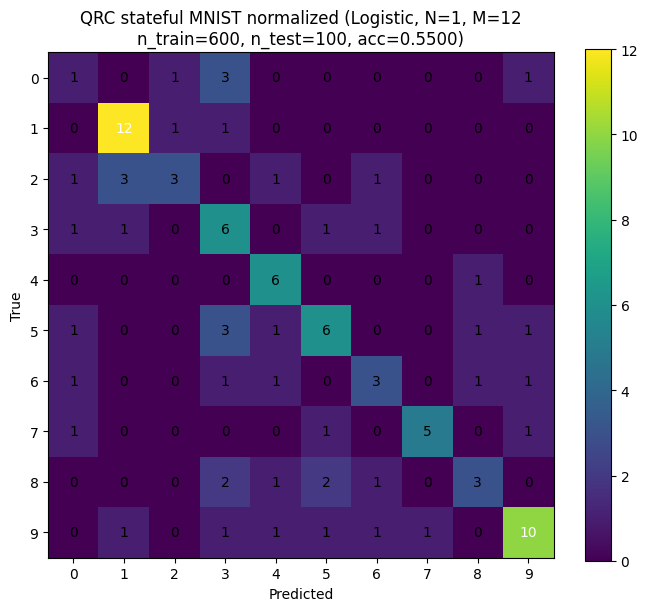

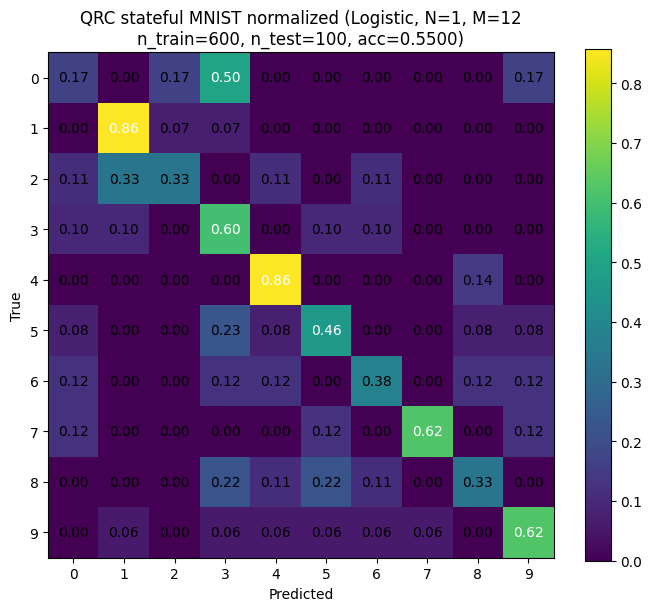

[Train] acc=0.5150
[Test ] acc=0.5500

Confusion matrix (test):
[[ 1  0  1  3  0  0  0  0  0  1]
 [ 0 12  1  1  0  0  0  0  0  0]
 [ 1  3  3  0  1  0  1  0  0  0]
 [ 1  1  0  6  0  1  1  0  0  0]
 [ 0  0  0  0  6  0  0  0  1  0]
 [ 1  0  0  3  1  6  0  0  1  1]
 [ 1  0  0  1  1  0  3  0  1  1]
 [ 1  0  0  0  0  1  0  5  0  1]
 [ 0  0  0  2  1  2  1  0  3  0]
 [ 0  1  0  1  1  1  1  1  0 10]]

Classification report (test):
              precision    recall  f1-score   support

           0     0.1667    0.1667    0.1667         6
           1     0.7059    0.8571    0.7742        14
           2     0.6000    0.3333    0.4286         9
           3     0.3529    0.6000    0.4444        10
           4     0.5455    0.8571    0.6667         7
           5     0.5455    0.4615    0.5000        13
           6     0.4286    0.3750    0.4000         8
           7     0.8333    0.6250    0.7143         8
           8     0.5000    0.3333    0.4000         9
           9     0.7143    0.6250

In [ ]:
if __name__ == "__main__":
    run_mnist_qrc_logreg(
        n_train=600,
        n_test=100,
        N=1,          # M=12
        alpha=1.0,
        beta=0.7,
        squeeze_r=0.3,
        seed_data=123,
        seed_proj=0,
        seed_qrc=43,
        carry_state=True
    )

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


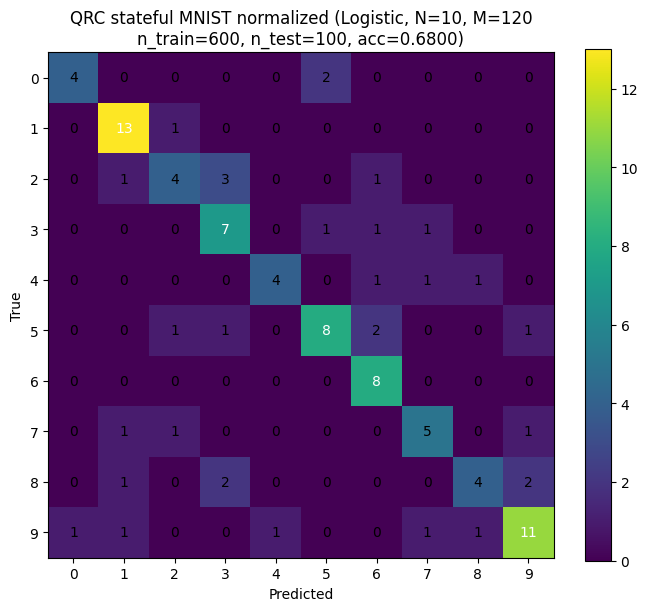

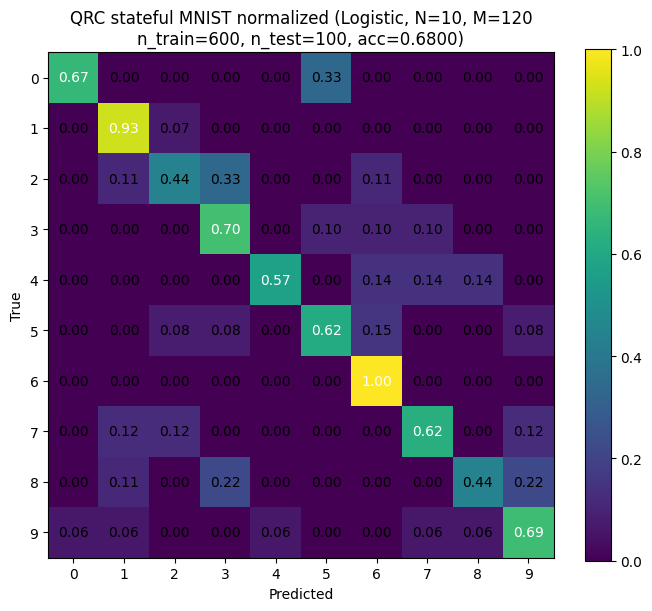

[Train] acc=0.9867
[Test ] acc=0.6800

Confusion matrix (test):
[[ 4  0  0  0  0  2  0  0  0  0]
 [ 0 13  1  0  0  0  0  0  0  0]
 [ 0  1  4  3  0  0  1  0  0  0]
 [ 0  0  0  7  0  1  1  1  0  0]
 [ 0  0  0  0  4  0  1  1  1  0]
 [ 0  0  1  1  0  8  2  0  0  1]
 [ 0  0  0  0  0  0  8  0  0  0]
 [ 0  1  1  0  0  0  0  5  0  1]
 [ 0  1  0  2  0  0  0  0  4  2]
 [ 1  1  0  0  1  0  0  1  1 11]]

Classification report (test):
              precision    recall  f1-score   support

           0     0.8000    0.6667    0.7273         6
           1     0.7647    0.9286    0.8387        14
           2     0.5714    0.4444    0.5000         9
           3     0.5385    0.7000    0.6087        10
           4     0.8000    0.5714    0.6667         7
           5     0.7273    0.6154    0.6667        13
           6     0.6154    1.0000    0.7619         8
           7     0.6250    0.6250    0.6250         8
           8     0.6667    0.4444    0.5333         9
           9     0.7333    0.6875

In [ ]:
if __name__ == "__main__":
    run_mnist_qrc_logreg(
        n_train=600,
        n_test=100,
        N=10,          # M=120
        alpha=1.0,
        beta=0.7,
        squeeze_r=0.3,
        seed_data=123,
        seed_proj=0,
        seed_qrc=43,
        carry_state=True
    )

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


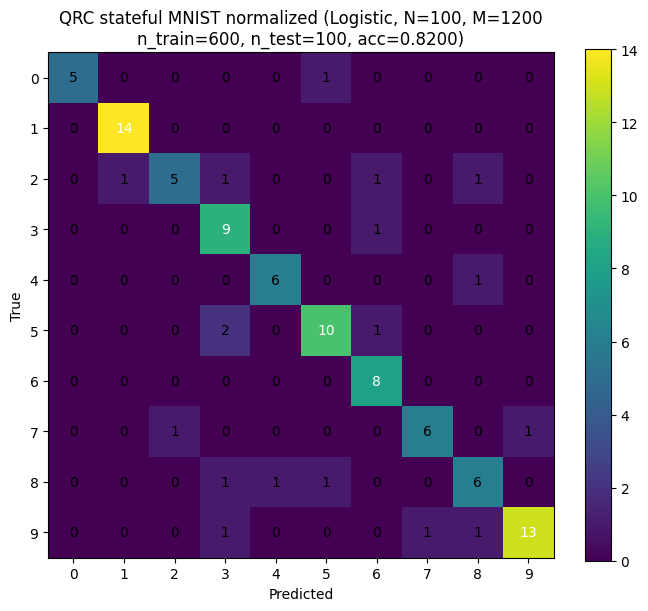

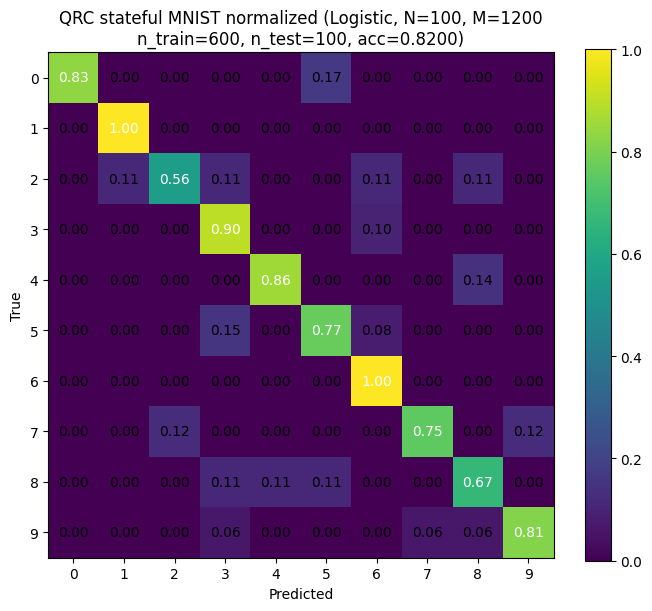

[Train] acc=1.0000
[Test ] acc=0.8200

Confusion matrix (test):
[[ 5  0  0  0  0  1  0  0  0  0]
 [ 0 14  0  0  0  0  0  0  0  0]
 [ 0  1  5  1  0  0  1  0  1  0]
 [ 0  0  0  9  0  0  1  0  0  0]
 [ 0  0  0  0  6  0  0  0  1  0]
 [ 0  0  0  2  0 10  1  0  0  0]
 [ 0  0  0  0  0  0  8  0  0  0]
 [ 0  0  1  0  0  0  0  6  0  1]
 [ 0  0  0  1  1  1  0  0  6  0]
 [ 0  0  0  1  0  0  0  1  1 13]]

Classification report (test):
              precision    recall  f1-score   support

           0     1.0000    0.8333    0.9091         6
           1     0.9333    1.0000    0.9655        14
           2     0.8333    0.5556    0.6667         9
           3     0.6429    0.9000    0.7500        10
           4     0.8571    0.8571    0.8571         7
           5     0.8333    0.7692    0.8000        13
           6     0.7273    1.0000    0.8421         8
           7     0.8571    0.7500    0.8000         8
           8     0.6667    0.6667    0.6667         9
           9     0.9286    0.8125

In [ ]:
if __name__ == "__main__":
    run_mnist_qrc_logreg(
        n_train=600,
        n_test=100,
        N=100,          # M=1200
        alpha=1.0,
        beta=0.7,
        squeeze_r=0.3,
        seed_data=123,
        seed_proj=0,
        seed_qrc=43,
        carry_state=True
    )

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


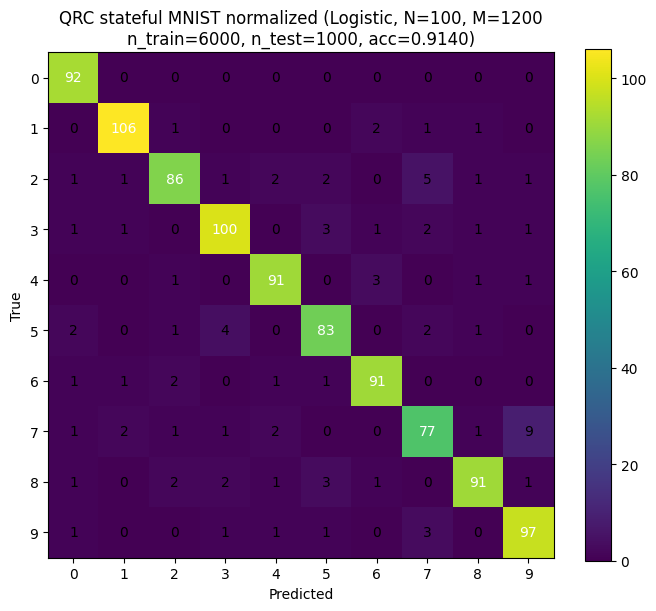

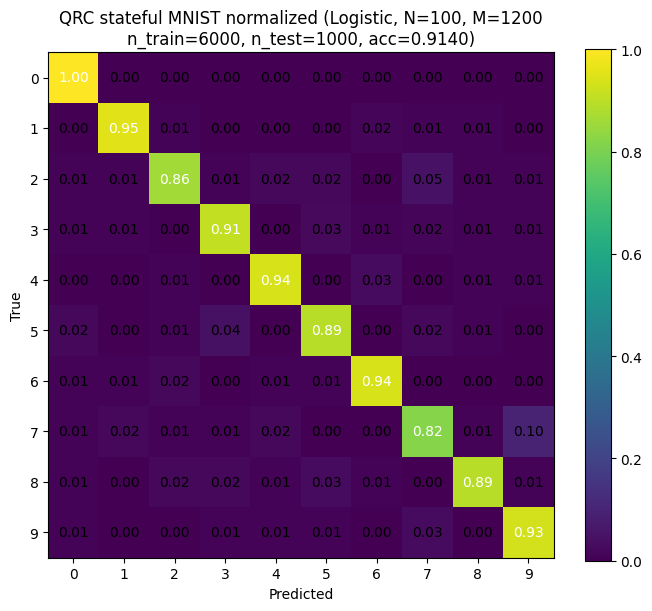

[Train] acc=1.0000
[Test ] acc=0.9140

Confusion matrix (test):
[[ 92   0   0   0   0   0   0   0   0   0]
 [  0 106   1   0   0   0   2   1   1   0]
 [  1   1  86   1   2   2   0   5   1   1]
 [  1   1   0 100   0   3   1   2   1   1]
 [  0   0   1   0  91   0   3   0   1   1]
 [  2   0   1   4   0  83   0   2   1   0]
 [  1   1   2   0   1   1  91   0   0   0]
 [  1   2   1   1   2   0   0  77   1   9]
 [  1   0   2   2   1   3   1   0  91   1]
 [  1   0   0   1   1   1   0   3   0  97]]

Classification report (test):
              precision    recall  f1-score   support

           0     0.9200    1.0000    0.9583        92
           1     0.9550    0.9550    0.9550       111
           2     0.9149    0.8600    0.8866       100
           3     0.9174    0.9091    0.9132       110
           4     0.9286    0.9381    0.9333        97
           5     0.8925    0.8925    0.8925        93
           6     0.9286    0.9381    0.9333        97
           7     0.8556    0.8191    0.83

In [ ]:
if __name__ == "__main__":
    run_mnist_qrc_logreg(
        n_train=6000,
        n_test=1000,
        N=100,          # M=1200
        alpha=1.0,
        beta=0.7,
        squeeze_r=0.3,
        seed_data=123,
        seed_proj=0,
        seed_qrc=43,
        carry_state=True
    )

**古典ESNによるMNIT分類**

(3-1), (3-2)の右図

In [ ]:
import numpy as np
from typing import Tuple, Optional, Dict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix as sk_confusion_matrix


# ============================================================
# 1) MNIST loader
# ============================================================
def load_mnist() -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    returns:
      x_train: uint8 (N,28,28)
      y_train: int  (N,)
      x_test : uint8 (N,28,28)
      y_test : int  (N,)
    """
    try:
        from tensorflow.keras.datasets import mnist
        (x_train, y_train), (x_test, y_test) = mnist.load_data()
        return x_train, y_train.astype(int), x_test, y_test.astype(int)
    except Exception as e:
        raise RuntimeError("MNISTを読み込めませんでした。tensorflow.keras を用意してください。") from e


# ============================================================
# 2) （元コードのまま残す：今回は使いません）
#    10x10 sliding patches stride=2 -> T=100, patch dim=100
# ============================================================
def patches_10x10_stride2(img28: np.ndarray) -> np.ndarray:
    """
    img28: (28,28) uint8 or float
    return: patches (T=100, 100) float64 in [0,1]
    """
    img = img28.astype(np.float64)
    if img.max() > 1.0:
        img = img / 255.0

    H, W = img.shape
    stride = 2
    ys = range(0, H - 10 + 1, stride)  # 0..18 step2 => 10 positions
    xs = range(0, W - 10 + 1, stride)  # 10 positions
    patches = []
    for y in ys:
        for x in xs:
            p = img[y:y + 10, x:x + 10].reshape(-1)  # 100
            patches.append(p)
    return np.stack(patches, axis=0)  # (100,100)


def build_projection_A10x100(seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    # 10x100, scale ~ 1/sqrt(100) で安定化
    A = rng.normal(0.0, 1.0 / np.sqrt(100.0), size=(10, 100))
    return A


def patches_to_U10(patches: np.ndarray, A10x100: np.ndarray) -> np.ndarray:
    """
    patches: (T,100)
    A10x100: (10,100)
    return: U10 (T,10)
    """
    U10 = patches @ A10x100.T
    return U10.astype(np.float64)


# ============================================================
# 2') 28x28 -> scalar time series u(t) of length 784
#     （左上から右へ、次の行へ：row-major で走査）
# ============================================================
def image28_to_scalar_sequence(img28: np.ndarray) -> np.ndarray:
    """
    img28: (28,28) uint8 or float
    return: U (T=784,) float64 in [0,1]
    """
    img = img28.astype(np.float64)
    if img.max() > 1.0:
        img = img / 255.0
    U = img.reshape(-1)  # length 784
    return U.astype(np.float64)


# ============================================================
# 3) ESN forward: あなたの提示コード
# ============================================================
def simulate_esn_states_tanh_scalar(
    M: int,
    U: np.ndarray,  # (T,) スカラー入力
    *,
    seed: int = 43,
    spectral_radius: float = 0.9,
    input_scale: float = 0.5,
    leak_rate: float = 1.0,
    bias_scale: float = 0.1,
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    """
    標準的 ESN:
      x_{t+1} = (1-leak)*x_t + leak*tanh( Wres x_t + Win u_t + b )
    Returns:
      S: (T,M) 状態列
      params: Wres, Win, b
    """
    U = np.asarray(U, float).reshape(-1)
    if U.ndim != 1:
        raise ValueError("U must be (T,)")
    T = U.shape[0]

    rng = np.random.default_rng(seed)

    # Win: (1,M)
    Win = rng.uniform(-1.0, 1.0, size=(1, M)) * float(input_scale)

    # Wres: (M,M) を作ってスペクトル半径調整
    Wres = rng.normal(0.0, 1.0, size=(M, M)) / np.sqrt(M)

    eigvals = np.linalg.eigvals(Wres)
    sr = np.max(np.abs(eigvals)) + 1e-12
    Wres = Wres * (float(spectral_radius) / sr)

    b = rng.uniform(-1.0, 1.0, size=M) * float(bias_scale)

    x = np.zeros(M, dtype=float)
    S = np.empty((T, M), dtype=float)

    for t in range(T):
        pre = x @ Wres + np.array([U[t]]) @ Win + b
        x_new = np.tanh(pre)
        x = (1.0 - leak_rate) * x + leak_rate * x_new
        S[t] = x

    params = {"Wres": Wres, "Win": Win, "b": b}
    return S, params


# （高速化用）params を固定して状態列だけ流す補助関数
def simulate_esn_states_tanh_scalar_given_params(
    U: np.ndarray,                  # (T,)
    params: Dict[str, np.ndarray],  # {"Wres","Win","b"}
    *,
    leak_rate: float = 1.0,
) -> np.ndarray:
    U = np.asarray(U, float).reshape(-1)
    if U.ndim != 1:
        raise ValueError("U must be (T,)")
    T = U.shape[0]

    Wres = params["Wres"]
    Win  = params["Win"]
    b    = params["b"]
    M = Wres.shape[0]

    x = np.zeros(M, dtype=float)
    S = np.empty((T, M), dtype=float)

    for t in range(T):
        pre = x @ Wres + np.array([U[t]]) @ Win + b
        x_new = np.tanh(pre)
        x = (1.0 - leak_rate) * x + leak_rate * x_new
        S[t] = x

    return S


# ============================================================
# 4) 1画像 -> ESN特徴 (M,) を作る（time-mean pooling）
# ============================================================
def esn_feature_from_image(
    img28: np.ndarray,
    *,
    N: int,  # 互換：M=12N
    seed_esn: int = 43,
    spectral_radius: float = 0.9,
    input_scale: float = 0.5,
    leak_rate: float = 1.0,
    bias_scale: float = 0.1,
    params_fixed: Optional[Dict[str, np.ndarray]] = None,
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    """
    return:
      feat: (M,) float32
      params_used: {"Wres","Win","b"} 以後の画像で再利用
    """
    U = image28_to_scalar_sequence(img28)  # (784,)
    M = 12 * N

    if params_fixed is None:
        S, params_used = simulate_esn_states_tanh_scalar(
            M=M, U=U,
            seed=seed_esn,
            spectral_radius=spectral_radius,
            input_scale=input_scale,
            leak_rate=leak_rate,
            bias_scale=bias_scale,
        )
    else:
        params_used = params_fixed
        S = simulate_esn_states_tanh_scalar_given_params(
            U=U, params=params_used, leak_rate=leak_rate
        )

    feat = S.mean(axis=0)  # (M,)
    return feat.astype(np.float32), params_used


# ============================================================
# 5) 混同行列の画像表示（値つき）
# ============================================================
def show_confusion_matrix_with_numbers(
    y_true,
    y_pred,
    *,
    labels=None,
    normalize: bool = False,
    title: str = "Confusion Matrix",
    figsize=(7, 6),
):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if labels is None:
        labels = np.unique(np.concatenate([y_true, y_pred]))

    cm = sk_confusion_matrix(y_true, y_pred, labels=labels)

    if normalize:
        cm = cm.astype(float)
        row_sum = cm.sum(axis=1, keepdims=True)
        cm = np.divide(cm, row_sum, out=np.zeros_like(cm), where=row_sum != 0)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    fig.colorbar(im, ax=ax)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    fmt = ".2f" if normalize else "d"
    vmax = float(np.max(cm)) if cm.size else 0.0
    thresh = vmax / 2.0 if vmax > 0 else 0.0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            ax.text(
                j, i, format(val, fmt),
                ha="center", va="center",
                color=("white" if val > thresh else "black"),
            )

    fig.tight_layout()
    plt.show()


# ============================================================
# 6) 全体：MNIST -> ESN特徴 -> LogisticRegression
# ============================================================
def run_mnist_esn_logreg(
    *,
    n_train: int = 6000,
    n_test: int = 1000,
    # ESN size
    N: int = 100,                 # M=12N
    # ESN params
    seed_esn: int = 43,
    spectral_radius: float = 0.9,
    input_scale: float = 0.5,
    leak_rate: float = 1.0,
    bias_scale: float = 0.1,
    # LogisticRegression params
    C: float = 1.0,               # 小さいほど正則化が強い
    max_iter: int = 400,
    solver: str = "lbfgs",
    # seeds
    seed_data: int = 123,
    seed_proj: int = 0,           # 互換のため残す（未使用）
):
    x_train, y_train, x_test, y_test = load_mnist()

    rng = np.random.default_rng(seed_data)
    idx_tr = rng.choice(len(x_train), size=n_train, replace=False)
    idx_te = rng.choice(len(x_test),  size=n_test,  replace=False)
    Xtr_img = x_train[idx_tr]
    ytr = y_train[idx_tr]
    Xte_img = x_test[idx_te]
    yte = y_test[idx_te]

    # 互換のため残す（未使用）
    _A_unused = build_projection_A10x100(seed=seed_proj)

    # 特徴抽出（ESNパラメータは全画像で固定）
    params_fixed = None

    Phi_tr = []
    for img in Xtr_img:
        feat, params_fixed = esn_feature_from_image(
            img,
            N=N,
            seed_esn=seed_esn,
            spectral_radius=spectral_radius,
            input_scale=input_scale,
            leak_rate=leak_rate,
            bias_scale=bias_scale,
            params_fixed=params_fixed,
        )
        Phi_tr.append(feat)
    Phi_tr = np.stack(Phi_tr, axis=0)  # (n_train, M)

    Phi_te = []
    for img in Xte_img:
        feat, _ = esn_feature_from_image(
            img,
            N=N,
            seed_esn=seed_esn,
            spectral_radius=spectral_radius,
            input_scale=input_scale,
            leak_rate=leak_rate,
            bias_scale=bias_scale,
            params_fixed=params_fixed,
        )
        Phi_te.append(feat)
    Phi_te = np.stack(Phi_te, axis=0)  # (n_test, M)

    # =========================
    # 標準化 + LogisticRegression
    # =========================
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(Phi_tr)
    Xte = scaler.transform(Phi_te)

    clf = LogisticRegression(
        penalty="l2",
        C=float(C),
        solver=str(solver),
        max_iter=int(max_iter),
        multi_class="multinomial",
    )
    clf.fit(Xtr, ytr)

    pred_tr = clf.predict(Xtr)
    pred_te = clf.predict(Xte)

    acc_tr = accuracy_score(ytr, pred_tr)
    acc_te = accuracy_score(yte, pred_te)

    show_confusion_matrix_with_numbers(
        yte, pred_te,
        labels=np.arange(10),
        normalize=False,
        title=f"ESN MNIST (Logistic, N={N}, M={12*N}\n"
        f"n_train={n_train}, n_test={n_test}, acc={acc_te:.4f})"
    )

    show_confusion_matrix_with_numbers(
        yte, pred_te,
        labels=np.arange(10),
        normalize=True,
        title=f"ESN MNIST (Logistic, N={N}, M={12*N}\n"
        f"n_train={n_train}, n_test={n_test}, acc={acc_te:.4f})"
    )

    print(f"[Train] acc={acc_tr:.4f}")
    print(f"[Test ] acc={acc_te:.4f}")
    print("\nConfusion matrix (test):")
    print(confusion_matrix(yte, pred_te))
    print("\nClassification report (test):")
    print(classification_report(yte, pred_te, digits=4))

    return acc_tr, acc_te, clf, scaler, params_fixed

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


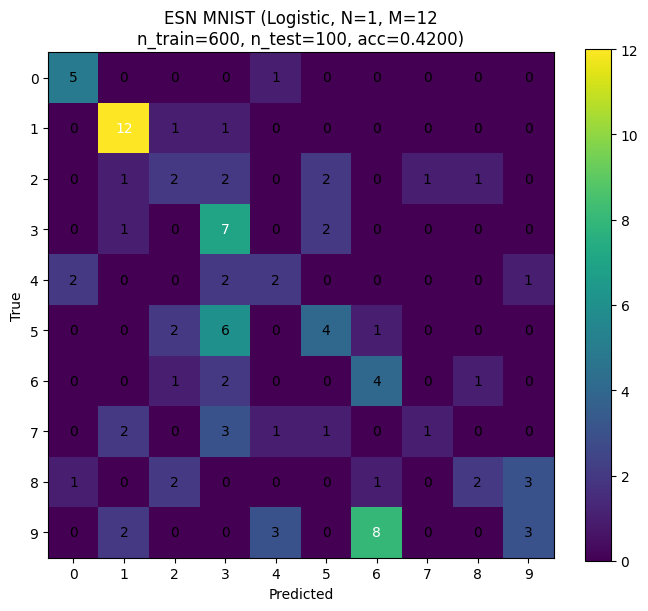

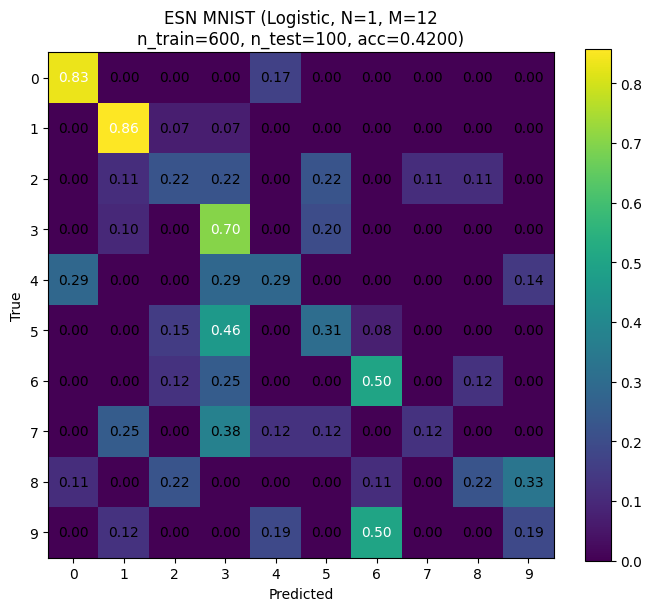

[Train] acc=0.5033
[Test ] acc=0.4200

Confusion matrix (test):
[[ 5  0  0  0  1  0  0  0  0  0]
 [ 0 12  1  1  0  0  0  0  0  0]
 [ 0  1  2  2  0  2  0  1  1  0]
 [ 0  1  0  7  0  2  0  0  0  0]
 [ 2  0  0  2  2  0  0  0  0  1]
 [ 0  0  2  6  0  4  1  0  0  0]
 [ 0  0  1  2  0  0  4  0  1  0]
 [ 0  2  0  3  1  1  0  1  0  0]
 [ 1  0  2  0  0  0  1  0  2  3]
 [ 0  2  0  0  3  0  8  0  0  3]]

Classification report (test):
              precision    recall  f1-score   support

           0     0.6250    0.8333    0.7143         6
           1     0.6667    0.8571    0.7500        14
           2     0.2500    0.2222    0.2353         9
           3     0.3043    0.7000    0.4242        10
           4     0.2857    0.2857    0.2857         7
           5     0.4444    0.3077    0.3636        13
           6     0.2857    0.5000    0.3636         8
           7     0.5000    0.1250    0.2000         8
           8     0.5000    0.2222    0.3077         9
           9     0.4286    0.1875

In [ ]:
if __name__ == "__main__":
  run_mnist_esn_logreg(
      n_train = 600,
      n_test = 100,
      N = 1,                 # M=12N
      seed_esn = 43,
      spectral_radius = 0.9,
      input_scale = 0.5,
      leak_rate = 1.0,
      bias_scale = 0.1,
      seed_data = 123,
      seed_proj = 0,          # 互換のため残す（未使用）
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


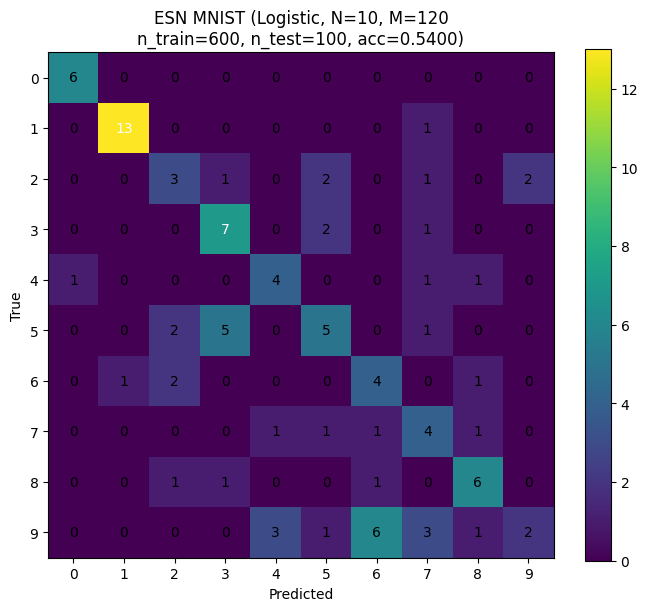

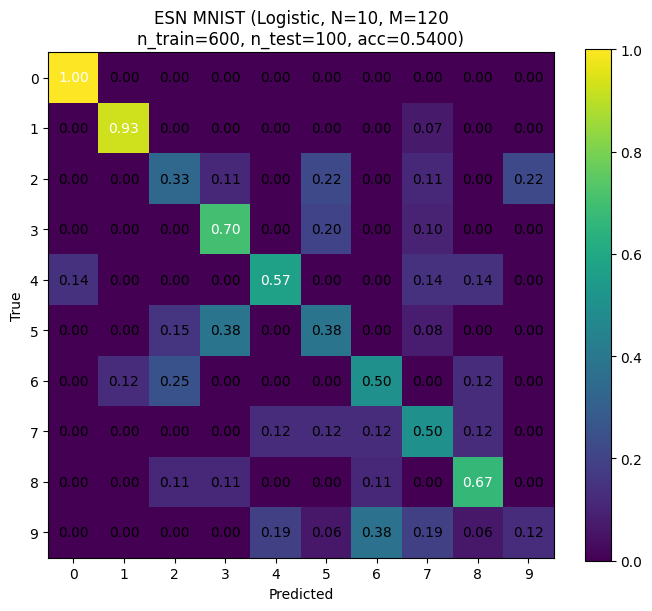

[Train] acc=0.5733
[Test ] acc=0.5400

Confusion matrix (test):
[[ 6  0  0  0  0  0  0  0  0  0]
 [ 0 13  0  0  0  0  0  1  0  0]
 [ 0  0  3  1  0  2  0  1  0  2]
 [ 0  0  0  7  0  2  0  1  0  0]
 [ 1  0  0  0  4  0  0  1  1  0]
 [ 0  0  2  5  0  5  0  1  0  0]
 [ 0  1  2  0  0  0  4  0  1  0]
 [ 0  0  0  0  1  1  1  4  1  0]
 [ 0  0  1  1  0  0  1  0  6  0]
 [ 0  0  0  0  3  1  6  3  1  2]]

Classification report (test):
              precision    recall  f1-score   support

           0     0.8571    1.0000    0.9231         6
           1     0.9286    0.9286    0.9286        14
           2     0.3750    0.3333    0.3529         9
           3     0.5000    0.7000    0.5833        10
           4     0.5000    0.5714    0.5333         7
           5     0.4545    0.3846    0.4167        13
           6     0.3333    0.5000    0.4000         8
           7     0.3333    0.5000    0.4000         8
           8     0.6000    0.6667    0.6316         9
           9     0.5000    0.1250

In [ ]:
if __name__ == "__main__":
  run_mnist_esn_logreg(
      n_train = 600,
      n_test = 100,
      N = 10,                 # M=12N
      seed_esn = 43,
      spectral_radius = 0.9,
      input_scale = 0.5,
      leak_rate = 1.0,
      bias_scale = 0.1,
      seed_data = 123,
      seed_proj = 0,          # 互換のため残す（未使用）
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


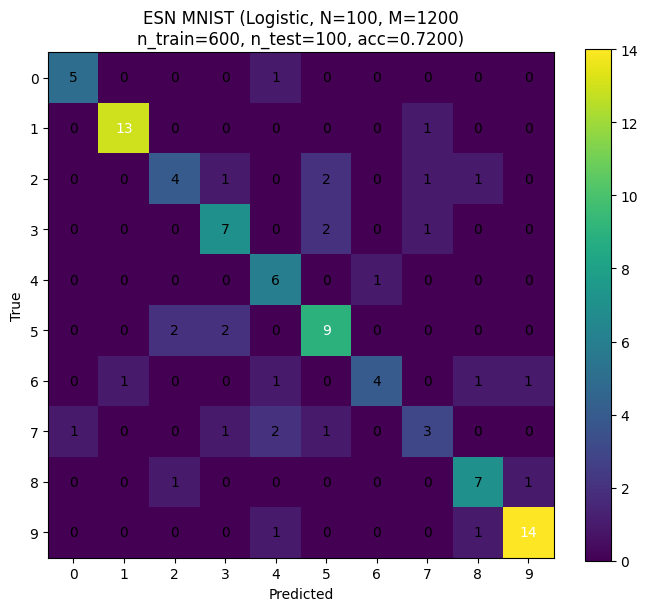

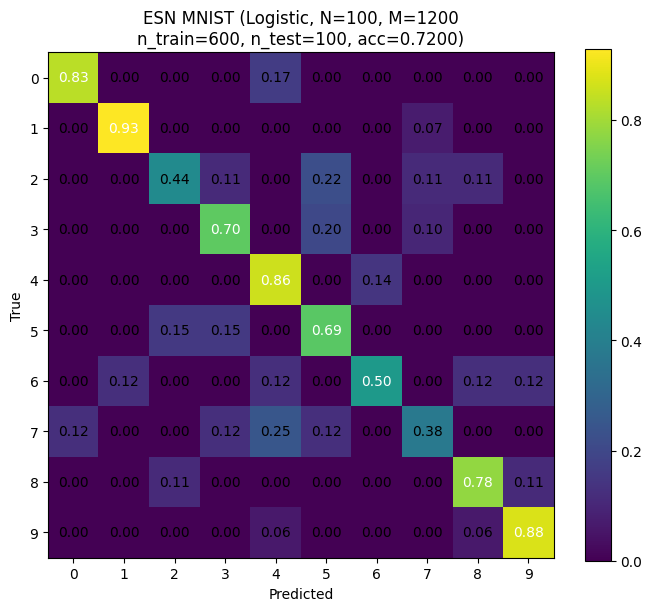

[Train] acc=0.7650
[Test ] acc=0.7200

Confusion matrix (test):
[[ 5  0  0  0  1  0  0  0  0  0]
 [ 0 13  0  0  0  0  0  1  0  0]
 [ 0  0  4  1  0  2  0  1  1  0]
 [ 0  0  0  7  0  2  0  1  0  0]
 [ 0  0  0  0  6  0  1  0  0  0]
 [ 0  0  2  2  0  9  0  0  0  0]
 [ 0  1  0  0  1  0  4  0  1  1]
 [ 1  0  0  1  2  1  0  3  0  0]
 [ 0  0  1  0  0  0  0  0  7  1]
 [ 0  0  0  0  1  0  0  0  1 14]]

Classification report (test):
              precision    recall  f1-score   support

           0     0.8333    0.8333    0.8333         6
           1     0.9286    0.9286    0.9286        14
           2     0.5714    0.4444    0.5000         9
           3     0.6364    0.7000    0.6667        10
           4     0.5455    0.8571    0.6667         7
           5     0.6429    0.6923    0.6667        13
           6     0.8000    0.5000    0.6154         8
           7     0.5000    0.3750    0.4286         8
           8     0.7000    0.7778    0.7368         9
           9     0.8750    0.8750

In [ ]:
if __name__ == "__main__":
  run_mnist_esn_logreg(
      n_train = 600,
      n_test = 100,
      N = 100,                 # M=12N
      seed_esn = 43,
      spectral_radius = 0.9,
      input_scale = 0.5,
      leak_rate = 1.0,
      bias_scale = 0.1,
      seed_data = 123,
      seed_proj = 0,          # 互換のため残す（未使用）
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


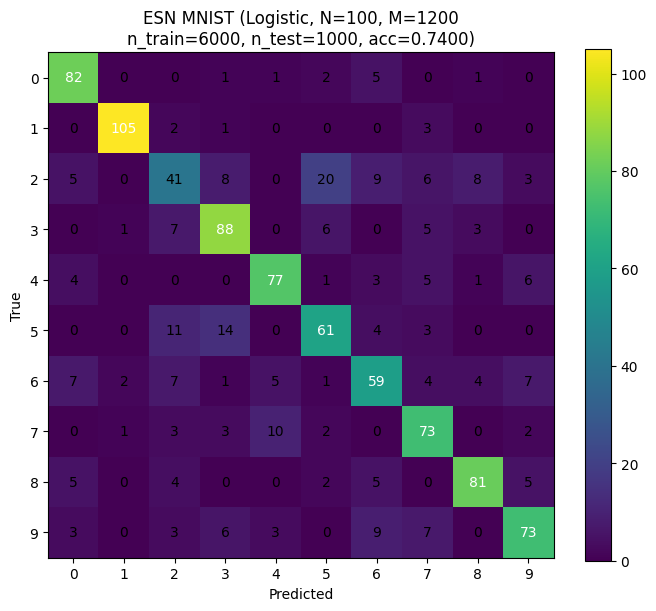

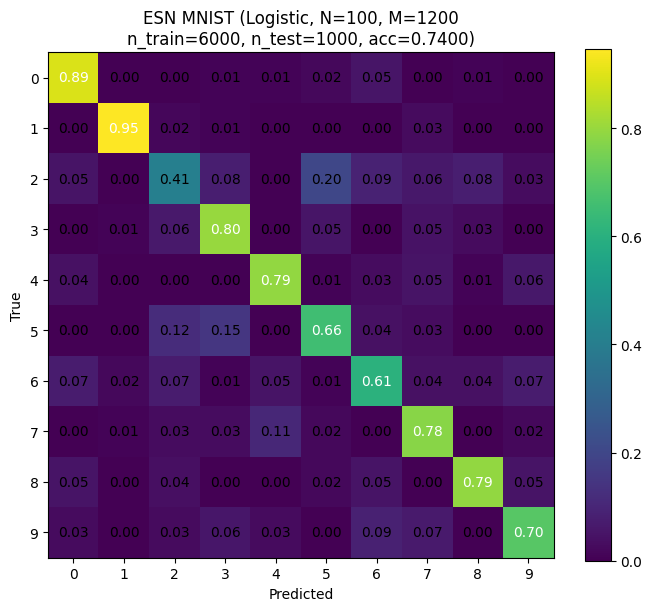

[Train] acc=0.7498
[Test ] acc=0.7400

Confusion matrix (test):
[[ 82   0   0   1   1   2   5   0   1   0]
 [  0 105   2   1   0   0   0   3   0   0]
 [  5   0  41   8   0  20   9   6   8   3]
 [  0   1   7  88   0   6   0   5   3   0]
 [  4   0   0   0  77   1   3   5   1   6]
 [  0   0  11  14   0  61   4   3   0   0]
 [  7   2   7   1   5   1  59   4   4   7]
 [  0   1   3   3  10   2   0  73   0   2]
 [  5   0   4   0   0   2   5   0  81   5]
 [  3   0   3   6   3   0   9   7   0  73]]

Classification report (test):
              precision    recall  f1-score   support

           0     0.7736    0.8913    0.8283        92
           1     0.9633    0.9459    0.9545       111
           2     0.5256    0.4100    0.4607       100
           3     0.7213    0.8000    0.7586       110
           4     0.8021    0.7938    0.7979        97
           5     0.6421    0.6559    0.6489        93
           6     0.6277    0.6082    0.6178        97
           7     0.6887    0.7766    0.73

In [ ]:
if __name__ == "__main__":
  run_mnist_esn_logreg(
      n_train = 6000,
      n_test = 1000,
      N = 100,                 # M=12N
      seed_esn = 43,
      spectral_radius = 0.9,
      input_scale = 0.5,
      leak_rate = 1.0,
      bias_scale = 0.1,
      seed_data = 123,
      seed_proj = 0,          # 互換のため残す（未使用）
)

**確率サンプリング版QRCによるMNIST分類**

(3-3)

In [ ]:
import numpy as np
from typing import Tuple, Optional
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ============================================================
# 1) MNIST loader
# ============================================================
def load_mnist() -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    returns:
      x_train: uint8 (N,28,28)
      y_train: int  (N,)
      x_test : uint8 (N,28,28)
      y_test : int  (N,)
    """
    try:
        from tensorflow.keras.datasets import mnist
        (x_train, y_train), (x_test, y_test) = mnist.load_data()
        return x_train, y_train.astype(int), x_test, y_test.astype(int)
    except Exception as e:
        raise RuntimeError("MNISTを読み込めませんでした。tensorflow.keras を用意してください。") from e


# ============================================================
# 2) （元コードのまま残す：今回は使いません）
#    10x10 sliding patches stride=2 -> T=100, patch dim=100
# ============================================================
def patches_10x10_stride2(img28: np.ndarray) -> np.ndarray:
    """
    img28: (28,28) uint8 or float
    return: patches (T=100, 100) float64 in [0,1]
    """
    img = img28.astype(np.float64)
    if img.max() > 1.0:
        img = img / 255.0

    H, W = img.shape
    stride = 2
    ys = range(0, H - 10 + 1, stride)  # 0..18 step2 => 10 positions
    xs = range(0, W - 10 + 1, stride)  # 10 positions
    patches = []
    for y in ys:
        for x in xs:
            p = img[y:y + 10, x:x + 10].reshape(-1)  # 100
            patches.append(p)
    return np.stack(patches, axis=0)  # (100,100)


def build_projection_A10x100(seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    # 10x100, scale ~ 1/sqrt(100) で安定化
    A = rng.normal(0.0, 1.0 / np.sqrt(100.0), size=(10, 100))
    return A


def patches_to_U10(patches: np.ndarray, A10x100: np.ndarray) -> np.ndarray:
    """
    patches: (T,100)
    A10x100: (10,100)
    return: U10 (T,10)
    """
    # (T,10) = (T,100) @ (100,10)
    U10 = patches @ A10x100.T
    return U10.astype(np.float64)


# ============================================================
# 2') 28x28 -> scalar time series u(t) of length 784
#     （左上から右へ、次の行へ：row-major で走査）
# ============================================================
def image28_to_scalar_sequence(img28: np.ndarray) -> np.ndarray:
    """
    img28: (28,28) uint8 or float
    return: U (T=784,) float64 in [0,1]
    """
    img = img28.astype(np.float64)
    if img.max() > 1.0:
        img = img / 255.0
    # 左上→右→次行…（row-major）
    U = img.reshape(-1)  # length 784
    return U.astype(np.float64)


# ============================================================
# 3) QRC forward: 1スカラー入力版（状態列Sを作る）
#    ※ out_prob をそのまま使わず、sampling/flip/shots平均に置換
# ============================================================
def qrc_forward_states_scalar(
    N: int,
    alpha: float,
    beta: float,
    squeeze_r: float,
    U: np.ndarray,                    # (T,) scalar input u(t)
    *,
    seed: int = 43,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win: Optional[np.ndarray] = None, # (1,M)
    Win_scale: float = 1.0,
    x0: Optional[np.ndarray] = None,  # (M,)
    carry_state: bool = True,
    shots: int = 10,
    flip_p: float = 0.10,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    return:
      S : (T,M)  状態列（0/1サンプルのshots平均）
      xT: (M,)   最終状態（無励起確率）
      Win: (1,M) 使用した入力マスク（再利用用）
    """
    U = np.asarray(U, dtype=float).reshape(-1)  # (T,)
    if U.ndim != 1:
        raise ValueError(f"U must be 1D (T,). got {U.shape}")
    T = U.shape[0]

    shots = int(shots)
    if shots <= 0:
        raise ValueError("shots must be a positive integer.")
    flip_p = float(flip_p)
    if not (0.0 <= flip_p <= 1.0):
        raise ValueError("flip_p must be in [0,1].")

    # 内部は (T,1) として扱う
    U1 = U.reshape(T, 1)  # (T,1)

    M = 12 * N
    rng = np.random.default_rng(seed)

    # Win: (1,M)
    if Win is None:
        Win = rng.uniform(-1.0, 1.0, size=(1, M)) * float(Win_scale)
    else:
        Win = np.asarray(Win, dtype=float)
        if Win.shape != (1, M):
            raise ValueError(f"Win must be shape (1,{M}). got {Win.shape}")

    # initial state (no-excitation prob)
    if x0 is None:
        x_state = np.zeros(M, dtype=float)
    else:
        x_state = np.asarray(x0, dtype=float).reshape(-1).copy()
        if x_state.size != M:
            raise ValueError(f"x0 must be length {M}. got {x_state.size}")
        x_state = np.clip(x_state, 0.0, 1.0)

    sqrt2 = np.sqrt(2.0)
    sqrt3 = np.sqrt(3.0)

    def bs50(a, b):
        return ((a + b) / sqrt2, (-a + b) / sqrt2)

    def apply_pairs_blockwise(vec: np.ndarray, pairs, mix_fn):
        outv = vec.copy()
        for blk in range(N):
            off = 12 * blk
            for (i, j) in pairs:
                a, b = vec[off + i], vec[off + j]
                ai, bj = mix_fn(a, b)
                outv[off + i] = ai
                outv[off + j] = bj
        return outv

    def tri_mix(a, b):
        return ((a + np.sqrt(2.0) * b) / sqrt3, ((-np.sqrt(2.0)) * a + b) / sqrt3)

    S = np.empty((T, M), dtype=float)

    for t in range(T):
        # (A) scalar(1) -> M via Win(1,M)
        u_vec = U1[t] @ Win  # (M,)

        if input_mode == "scale":
            u_vec = float(beta) * u_vec
        elif input_mode == "replace":
            pass
        else:
            raise ValueError('input_mode must be "scale" or "replace".')

        # (B) injection
        p = np.clip(x_state, 0.0, 1.0)
        r_uni = rng.random(M)
        inject_mask = (r_uni >= p)

        if sign_mode == "pm":
            signs = rng.integers(0, 2, size=M) * 2 - 1
        elif sign_mode == "plus":
            signs = np.ones(M, dtype=float)
        else:
            raise ValueError('sign_mode must be "pm" or "plus".')

        s = np.where(inject_mask, signs * float(alpha), 0.0)

        # (C) interferometer
        pairs_adj = [(k, k + 1) for k in range(0, 12, 2)]
        t2 = apply_pairs_blockwise(s, pairs_adj, bs50)

        rvec = t2.copy()
        for blk in range(N - 1, 0, -1):
            rvec[12 * blk + 3] = t2[12 * (blk - 1) + 3]
            rvec[12 * blk + 8] = t2[12 * (blk - 1) + 8]
        rvec[3] = 0.0
        rvec[8] = 0.0

        pairs_step4 = [(0, 2), (1, 3), (6, 5), (8, 10), (11, 9)]
        v = apply_pairs_blockwise(rvec, pairs_step4, bs50)

        pairs_step5 = [(4, 3), (7, 8)]
        wnet = apply_pairs_blockwise(v, pairs_step5, tri_mix)

        # (D) combine
        fin = (wnet + u_vec) / sqrt2

        # (E) nonlinearity -> out_prob（ここまでは同じ）
        coef = 1.0 / np.cosh(squeeze_r)
        tanh_r = np.tanh(squeeze_r)
        log_p0 = np.log(coef) - (np.abs(fin) ** 2) + tanh_r * (fin ** 2)

        re = np.real(log_p0)
        im = np.imag(log_p0)
        re = np.clip(re, -700.0, 50.0)
        p0_like = np.exp(re + 1j * im)

        out_prob = 1.0 - (p0_like / float(norm_const))
        out_prob = np.clip(np.real(out_prob).astype(float), 0.0, 1.0)

        # ---- sampling / flip / shots平均 ----
        samples_sum = np.zeros(M, dtype=float)
        for _ in range(shots):
            sample = (rng.random(M) < out_prob).astype(np.int8)  # 0/1
            if flip_p > 0.0:
                flip = (rng.random(M) < flip_p).astype(np.int8)  # 0/1
                sample = sample ^ flip
            samples_sum += sample.astype(float)

        out_mean01 = samples_sum / shots  # (M,) in [0,1]
        S[t] = out_mean01

        # 状態更新（無励起確率として）
        if carry_state:
            x_state = np.clip(1.0 - out_mean01, 0.0, 1.0)

    xT = x_state.copy()
    return S, xT, Win


# ============================================================
# 4) 1画像 -> QRC特徴 (M,) を作る（time-mean pooling）
# ============================================================
def qrc_feature_from_image(
    img28: np.ndarray,
    *,
    A10x100: np.ndarray,              # 互換のため残す（今回は未使用）
    N: int,
    alpha: float,
    beta: float,
    squeeze_r: float,
    seed_qrc: int,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win: Optional[np.ndarray] = None,
    Win_scale: float = 1.0,
    carry_state: bool = True,
    shots: int = 10,
    flip_p: float = 0.10,
) -> Tuple[np.ndarray, np.ndarray]:
    # 28x28 を左上から走査して T=784 のスカラー系列へ
    U = image28_to_scalar_sequence(img28)  # (784,)

    S, xT, Win_used = qrc_forward_states_scalar(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U=U,
        seed=seed_qrc, norm_const=norm_const,
        sign_mode=sign_mode, input_mode=input_mode,
        Win=Win, Win_scale=Win_scale,
        x0=None, carry_state=carry_state,
        shots=shots, flip_p=flip_p
    )

    feat = S.mean(axis=0)  # (M,)
    return feat.astype(np.float32), Win_used

# ============================================================
# 5) 混同行列の画像表示（値つき）
# ============================================================
def show_confusion_matrix_with_numbers(
    y_true,
    y_pred,
    *,
    labels=None,
    normalize: bool = False,
    title: str = "Confusion Matrix",
    figsize=(7, 6),
):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if labels is None:
        labels = np.unique(np.concatenate([y_true, y_pred]))

    cm = sk_confusion_matrix(y_true, y_pred, labels=labels)

    if normalize:
        cm = cm.astype(float)
        row_sum = cm.sum(axis=1, keepdims=True)
        cm = np.divide(cm, row_sum, out=np.zeros_like(cm), where=row_sum != 0)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    fig.colorbar(im, ax=ax)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    fmt = ".2f" if normalize else "d"
    vmax = float(np.max(cm)) if cm.size else 0.0
    thresh = vmax / 2.0 if vmax > 0 else 0.0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            ax.text(
                j, i, format(val, fmt),
                ha="center", va="center",
                color=("white" if val > thresh else "black"),
            )

    fig.tight_layout()
    plt.show()

# ============================================================
# 5) 全体：MNIST -> QRC特徴 -> ロジ回帰
# ============================================================
def run_mnist_qrc_logreg_sampled(
    *,
    n_train: int = 6000,
    n_test: int = 1000,
    # QRC params
    N: int = 100,            # M=12N
    alpha: float = 1.0,
    beta: float = 0.7,
    squeeze_r: float = 0.3,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win_scale: float = 1.0,
    carry_state: bool = True,
    shots: int = 10,
    flip_p: float = 0.075,
    # seeds
    seed_data: int = 123,
    seed_proj: int = 0,
    seed_qrc: int = 43,
):
    x_train, y_train, x_test, y_test = load_mnist()

    rng = np.random.default_rng(seed_data)
    idx_tr = rng.choice(len(x_train), size=n_train, replace=False)
    idx_te = rng.choice(len(x_test),  size=n_test,  replace=False)
    Xtr_img = x_train[idx_tr]
    ytr = y_train[idx_tr]
    Xte_img = x_test[idx_te]
    yte = y_test[idx_te]

    # （元コード互換のため残す：今回は未使用）
    A = build_projection_A10x100(seed=seed_proj)

    # 特徴抽出（Winは全画像で固定）
    Win_fixed = None

    Phi_tr = []
    for img in Xtr_img:
        feat, Win_fixed = qrc_feature_from_image(
            img,
            A10x100=A,
            N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
            seed_qrc=seed_qrc,
            norm_const=norm_const, sign_mode=sign_mode, input_mode=input_mode,
            Win=Win_fixed, Win_scale=Win_scale,
            carry_state=carry_state,
            shots=shots, flip_p=flip_p
        )
        Phi_tr.append(feat)
    Phi_tr = np.stack(Phi_tr, axis=0)  # (n_train, M)

    Phi_te = []
    for img in Xte_img:
        feat, _ = qrc_feature_from_image(
            img,
            A10x100=A,
            N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
            seed_qrc=seed_qrc,
            norm_const=norm_const, sign_mode=sign_mode, input_mode=input_mode,
            Win=Win_fixed, Win_scale=Win_scale,
            carry_state=carry_state,
            shots=shots, flip_p=flip_p
        )
        Phi_te.append(feat)
    Phi_te = np.stack(Phi_te, axis=0)  # (n_test, M)

    # 標準化 + ロジ回帰
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(Phi_tr)
    Xte = scaler.transform(Phi_te)

    clf = LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        max_iter=400,
        multi_class="multinomial"
    )
    clf.fit(Xtr, ytr)

    pred_tr = clf.predict(Xtr)
    pred_te = clf.predict(Xte)

    acc_tr = accuracy_score(ytr, pred_tr)
    acc_te = accuracy_score(yte, pred_te)

    show_confusion_matrix_with_numbers(
        yte, pred_te,
        labels=np.arange(10),
        normalize=False,
        title=f"QRC MNIST (Logistic, sampled, N={N}, M={12*N}\n"
        f"n_train={n_train}, n_test={n_test}, acc={acc_te:.4f}\n"
        f"shots={shots}, flip_p={flip_p})"
    )

    show_confusion_matrix_with_numbers(
        yte, pred_te,
        labels=np.arange(10),
        normalize=True,
        title=f"QRC MNIST (Logistic, sampled, N={N}, M={12*N}\n"
        f"n_train={n_train}, n_test={n_test}, acc={acc_te:.4f}\n"
        f"shots={shots}, flip_p={flip_p})"
    )

    print(f"[Train] acc={acc_tr:.4f}")
    print(f"[Test ] acc={acc_te:.4f}")
    print("\nConfusion matrix (test):")
    print(confusion_matrix(yte, pred_te))
    print("\nClassification report (test):")
    print(classification_report(yte, pred_te, digits=4))

    return acc_tr, acc_te, clf, scaler, Win_fixed, A

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


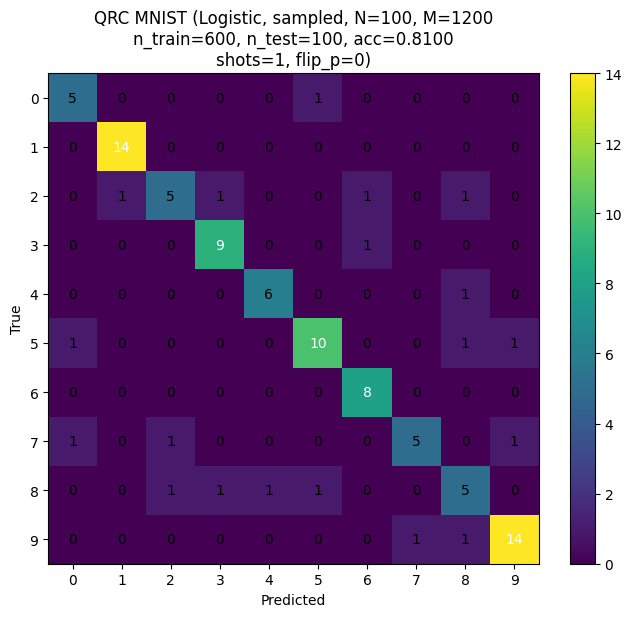

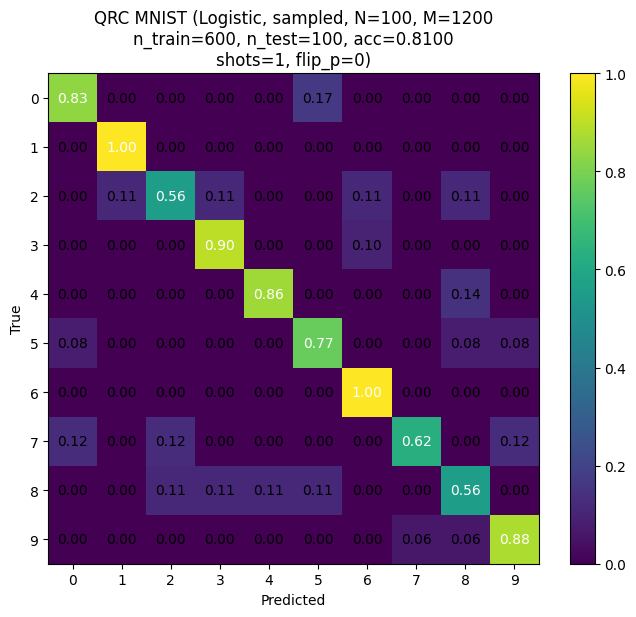

[Train] acc=1.0000
[Test ] acc=0.8100

Confusion matrix (test):
[[ 5  0  0  0  0  1  0  0  0  0]
 [ 0 14  0  0  0  0  0  0  0  0]
 [ 0  1  5  1  0  0  1  0  1  0]
 [ 0  0  0  9  0  0  1  0  0  0]
 [ 0  0  0  0  6  0  0  0  1  0]
 [ 1  0  0  0  0 10  0  0  1  1]
 [ 0  0  0  0  0  0  8  0  0  0]
 [ 1  0  1  0  0  0  0  5  0  1]
 [ 0  0  1  1  1  1  0  0  5  0]
 [ 0  0  0  0  0  0  0  1  1 14]]

Classification report (test):
              precision    recall  f1-score   support

           0     0.7143    0.8333    0.7692         6
           1     0.9333    1.0000    0.9655        14
           2     0.7143    0.5556    0.6250         9
           3     0.8182    0.9000    0.8571        10
           4     0.8571    0.8571    0.8571         7
           5     0.8333    0.7692    0.8000        13
           6     0.8000    1.0000    0.8889         8
           7     0.8333    0.6250    0.7143         8
           8     0.5556    0.5556    0.5556         9
           9     0.8750    0.8750

In [ ]:
if __name__ == "__main__":
    run_mnist_qrc_logreg_sampled(
        n_train=600,
        n_test=100,
        N=100,          # M=1200
        alpha=1.0,
        beta=0.7,
        squeeze_r=0.3,
        shots = 1,
        flip_p = 0,
        seed_data=123,
        seed_proj=0,
        seed_qrc=43,
        carry_state=True
    )

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


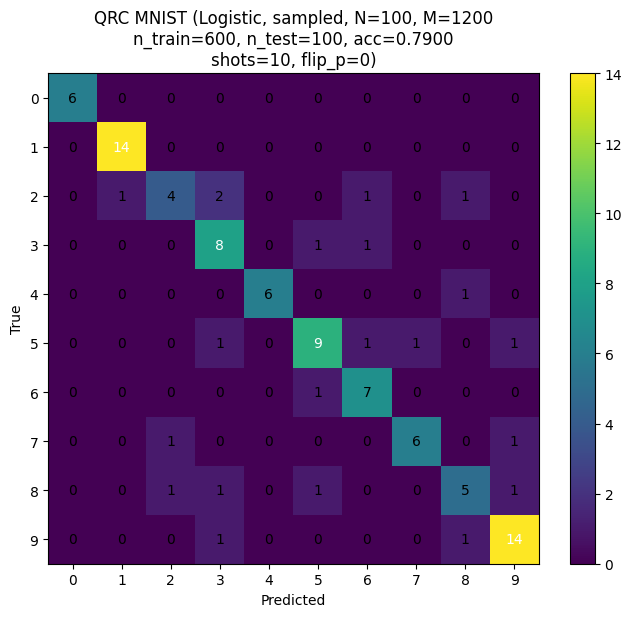

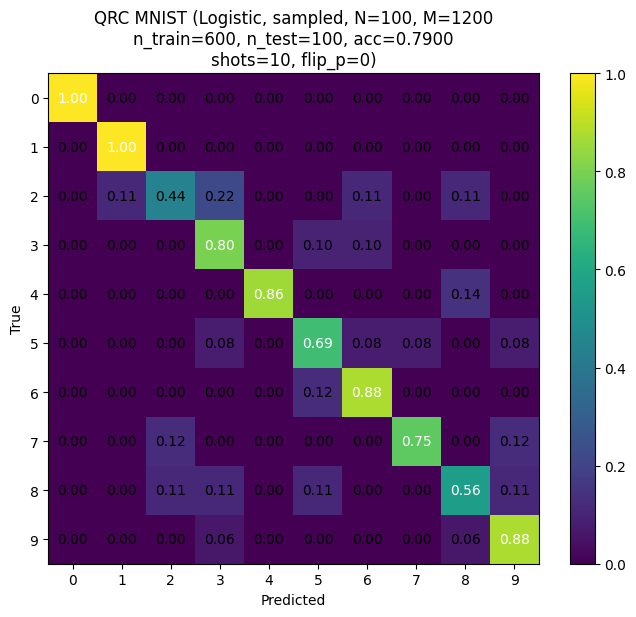

[Train] acc=1.0000
[Test ] acc=0.7900

Confusion matrix (test):
[[ 6  0  0  0  0  0  0  0  0  0]
 [ 0 14  0  0  0  0  0  0  0  0]
 [ 0  1  4  2  0  0  1  0  1  0]
 [ 0  0  0  8  0  1  1  0  0  0]
 [ 0  0  0  0  6  0  0  0  1  0]
 [ 0  0  0  1  0  9  1  1  0  1]
 [ 0  0  0  0  0  1  7  0  0  0]
 [ 0  0  1  0  0  0  0  6  0  1]
 [ 0  0  1  1  0  1  0  0  5  1]
 [ 0  0  0  1  0  0  0  0  1 14]]

Classification report (test):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         6
           1     0.9333    1.0000    0.9655        14
           2     0.6667    0.4444    0.5333         9
           3     0.6154    0.8000    0.6957        10
           4     1.0000    0.8571    0.9231         7
           5     0.7500    0.6923    0.7200        13
           6     0.7000    0.8750    0.7778         8
           7     0.8571    0.7500    0.8000         8
           8     0.6250    0.5556    0.5882         9
           9     0.8235    0.8750

In [ ]:
if __name__ == "__main__":
    run_mnist_qrc_logreg_sampled(
        n_train=600,
        n_test=100,
        N=100,          # M=1200
        alpha=1.0,
        beta=0.7,
        squeeze_r=0.3,
        shots = 10,
        flip_p = 0,
        seed_data=123,
        seed_proj=0,
        seed_qrc=43,
        carry_state=True
    )

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


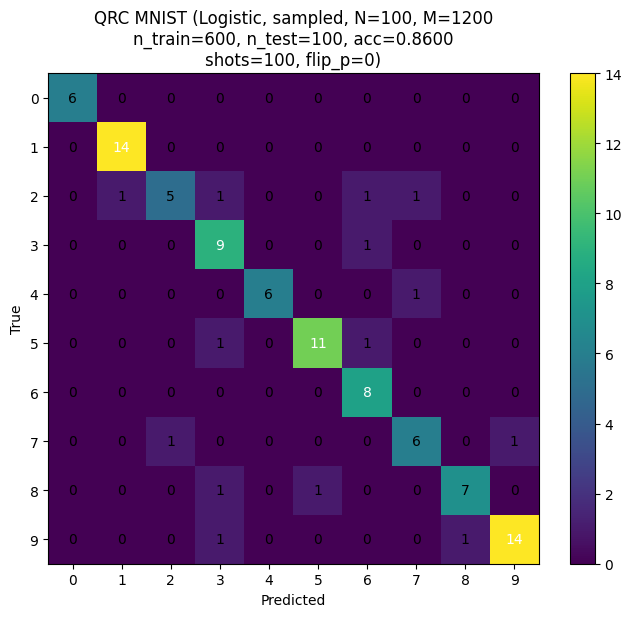

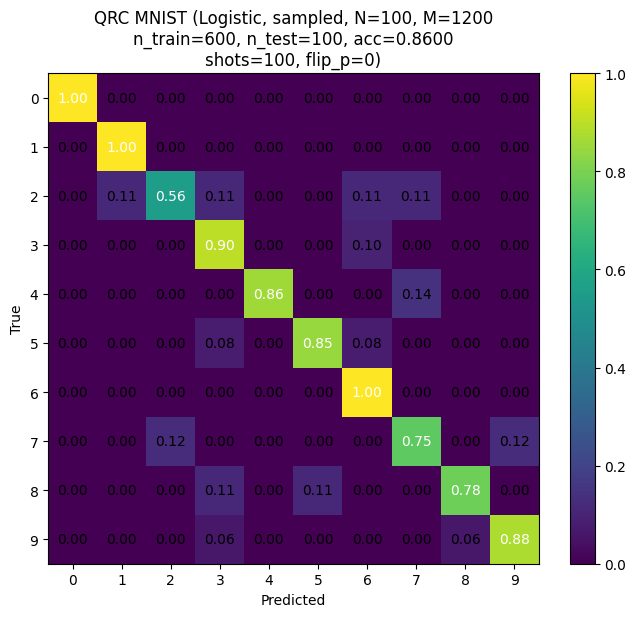

[Train] acc=1.0000
[Test ] acc=0.8600

Confusion matrix (test):
[[ 6  0  0  0  0  0  0  0  0  0]
 [ 0 14  0  0  0  0  0  0  0  0]
 [ 0  1  5  1  0  0  1  1  0  0]
 [ 0  0  0  9  0  0  1  0  0  0]
 [ 0  0  0  0  6  0  0  1  0  0]
 [ 0  0  0  1  0 11  1  0  0  0]
 [ 0  0  0  0  0  0  8  0  0  0]
 [ 0  0  1  0  0  0  0  6  0  1]
 [ 0  0  0  1  0  1  0  0  7  0]
 [ 0  0  0  1  0  0  0  0  1 14]]

Classification report (test):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         6
           1     0.9333    1.0000    0.9655        14
           2     0.8333    0.5556    0.6667         9
           3     0.6923    0.9000    0.7826        10
           4     1.0000    0.8571    0.9231         7
           5     0.9167    0.8462    0.8800        13
           6     0.7273    1.0000    0.8421         8
           7     0.7500    0.7500    0.7500         8
           8     0.8750    0.7778    0.8235         9
           9     0.9333    0.8750

In [ ]:
if __name__ == "__main__":
    run_mnist_qrc_logreg_sampled(
        n_train=600,
        n_test=100,
        N=100,          # M=1200
        alpha=1.0,
        beta=0.7,
        squeeze_r=0.3,
        shots = 100,
        flip_p = 0,
        seed_data=123,
        seed_proj=0,
        seed_qrc=43,
        carry_state=True
    )

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


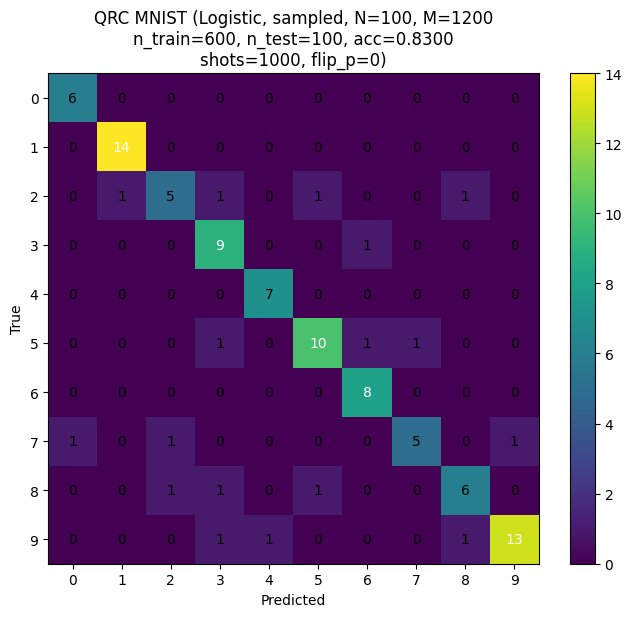

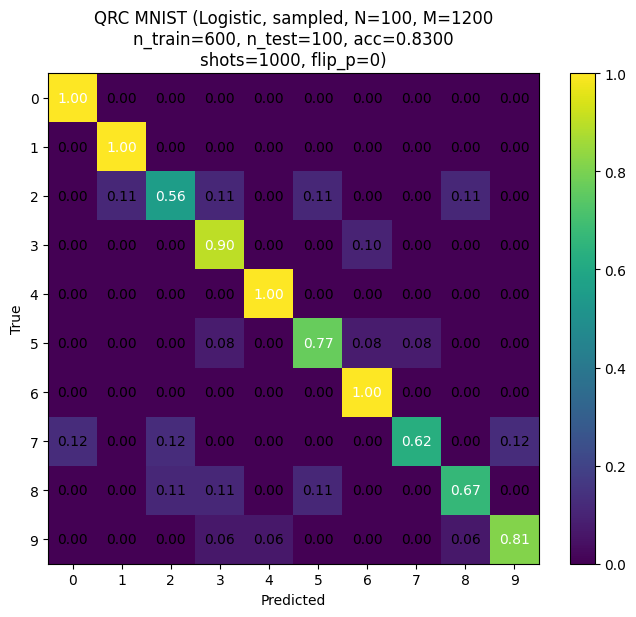

[Train] acc=1.0000
[Test ] acc=0.8300

Confusion matrix (test):
[[ 6  0  0  0  0  0  0  0  0  0]
 [ 0 14  0  0  0  0  0  0  0  0]
 [ 0  1  5  1  0  1  0  0  1  0]
 [ 0  0  0  9  0  0  1  0  0  0]
 [ 0  0  0  0  7  0  0  0  0  0]
 [ 0  0  0  1  0 10  1  1  0  0]
 [ 0  0  0  0  0  0  8  0  0  0]
 [ 1  0  1  0  0  0  0  5  0  1]
 [ 0  0  1  1  0  1  0  0  6  0]
 [ 0  0  0  1  1  0  0  0  1 13]]

Classification report (test):
              precision    recall  f1-score   support

           0     0.8571    1.0000    0.9231         6
           1     0.9333    1.0000    0.9655        14
           2     0.7143    0.5556    0.6250         9
           3     0.6923    0.9000    0.7826        10
           4     0.8750    1.0000    0.9333         7
           5     0.8333    0.7692    0.8000        13
           6     0.8000    1.0000    0.8889         8
           7     0.8333    0.6250    0.7143         8
           8     0.7500    0.6667    0.7059         9
           9     0.9286    0.8125

In [ ]:
if __name__ == "__main__":
    run_mnist_qrc_logreg_sampled(
        n_train=600,
        n_test=100,
        N=100,          # M=1200
        alpha=1.0,
        beta=0.7,
        squeeze_r=0.3,
        shots = 1000,
        flip_p = 0,
        seed_data=123,
        seed_proj=0,
        seed_qrc=43,
        carry_state=True
    )

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


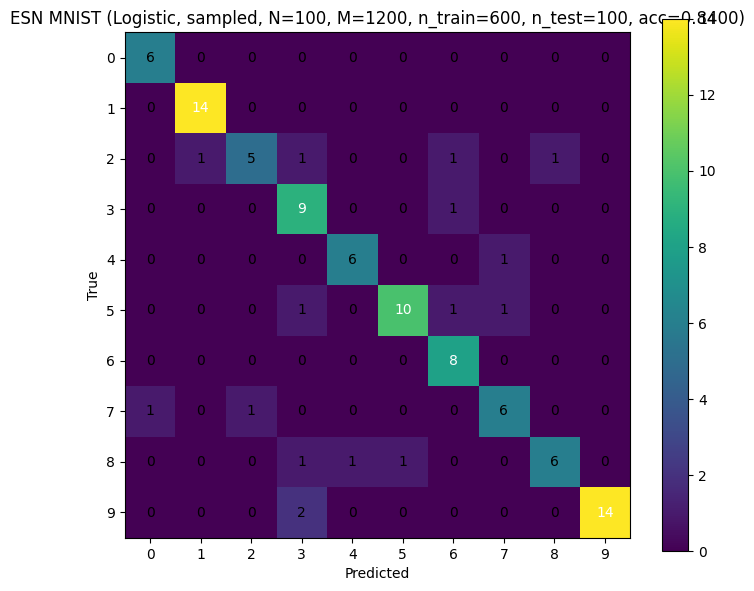

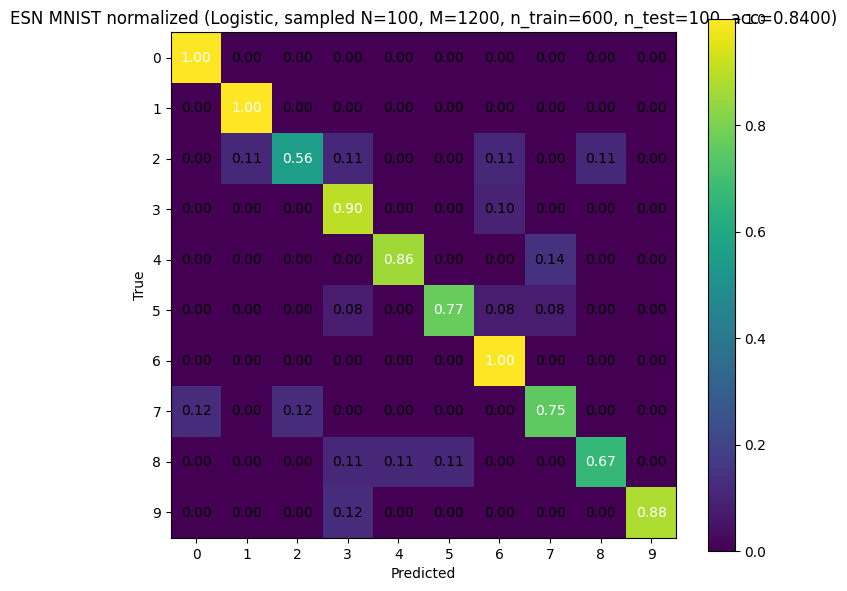

[Train] acc=1.0000
[Test ] acc=0.8400

Confusion matrix (test):
[[ 6  0  0  0  0  0  0  0  0  0]
 [ 0 14  0  0  0  0  0  0  0  0]
 [ 0  1  5  1  0  0  1  0  1  0]
 [ 0  0  0  9  0  0  1  0  0  0]
 [ 0  0  0  0  6  0  0  1  0  0]
 [ 0  0  0  1  0 10  1  1  0  0]
 [ 0  0  0  0  0  0  8  0  0  0]
 [ 1  0  1  0  0  0  0  6  0  0]
 [ 0  0  0  1  1  1  0  0  6  0]
 [ 0  0  0  2  0  0  0  0  0 14]]

Classification report (test):
              precision    recall  f1-score   support

           0     0.8571    1.0000    0.9231         6
           1     0.9333    1.0000    0.9655        14
           2     0.8333    0.5556    0.6667         9
           3     0.6429    0.9000    0.7500        10
           4     0.8571    0.8571    0.8571         7
           5     0.9091    0.7692    0.8333        13
           6     0.7273    1.0000    0.8421         8
           7     0.7500    0.7500    0.7500         8
           8     0.8571    0.6667    0.7500         9
           9     1.0000    0.8750

In [ ]:
if __name__ == "__main__":
    run_mnist_qrc_logreg_sampled(
        n_train=600,
        n_test=100,
        N=100,          # M=1200
        alpha=1.0,
        beta=0.7,
        squeeze_r=0.3,
        shots = 1,
        flip_p = 0.075,
        seed_data=123,
        seed_proj=0,
        seed_qrc=43,
        carry_state=True
    )

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


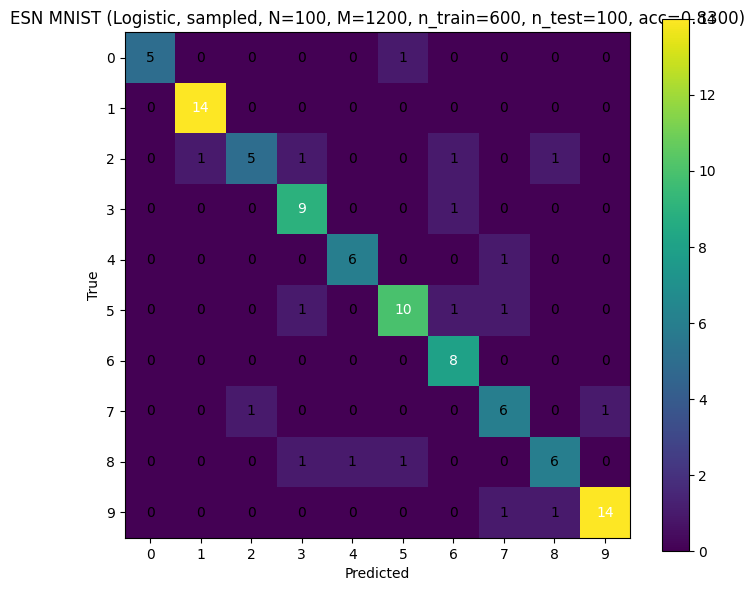

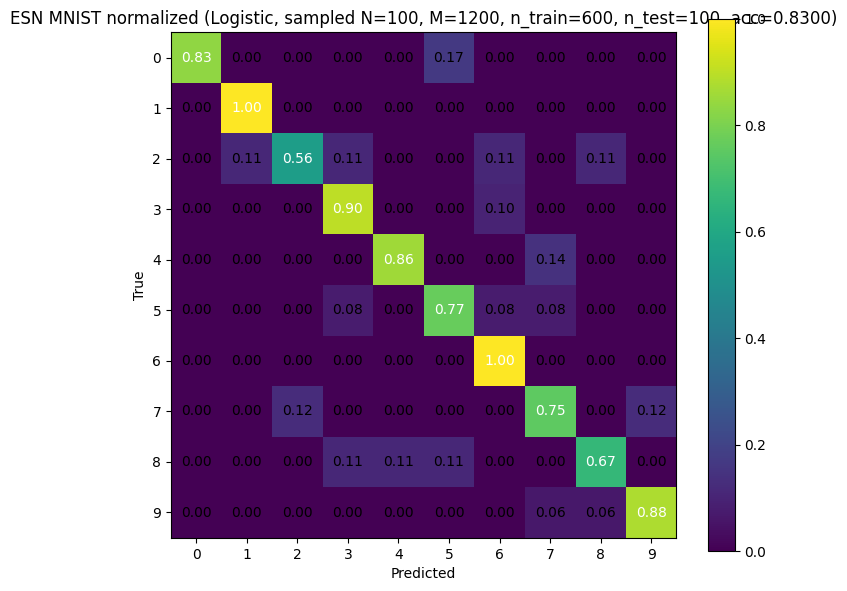

[Train] acc=1.0000
[Test ] acc=0.8300

Confusion matrix (test):
[[ 5  0  0  0  0  1  0  0  0  0]
 [ 0 14  0  0  0  0  0  0  0  0]
 [ 0  1  5  1  0  0  1  0  1  0]
 [ 0  0  0  9  0  0  1  0  0  0]
 [ 0  0  0  0  6  0  0  1  0  0]
 [ 0  0  0  1  0 10  1  1  0  0]
 [ 0  0  0  0  0  0  8  0  0  0]
 [ 0  0  1  0  0  0  0  6  0  1]
 [ 0  0  0  1  1  1  0  0  6  0]
 [ 0  0  0  0  0  0  0  1  1 14]]

Classification report (test):
              precision    recall  f1-score   support

           0     1.0000    0.8333    0.9091         6
           1     0.9333    1.0000    0.9655        14
           2     0.8333    0.5556    0.6667         9
           3     0.7500    0.9000    0.8182        10
           4     0.8571    0.8571    0.8571         7
           5     0.8333    0.7692    0.8000        13
           6     0.7273    1.0000    0.8421         8
           7     0.6667    0.7500    0.7059         8
           8     0.7500    0.6667    0.7059         9
           9     0.9333    0.8750

In [ ]:
if __name__ == "__main__":
    run_mnist_qrc_logreg_sampled(
        n_train=600,
        n_test=100,
        N=100,          # M=1200
        alpha=1.0,
        beta=0.7,
        squeeze_r=0.3,
        shots = 10,
        flip_p = 0.075,
        seed_data=123,
        seed_proj=0,
        seed_qrc=43,
        carry_state=True
    )

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


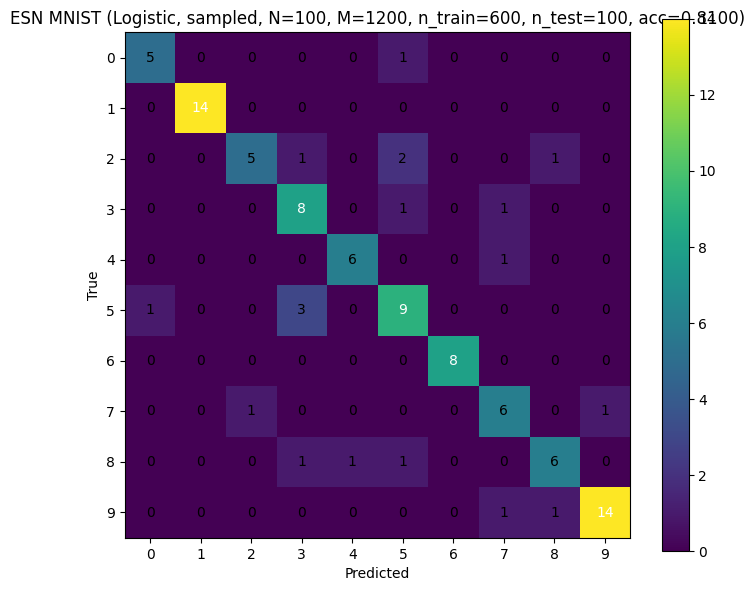

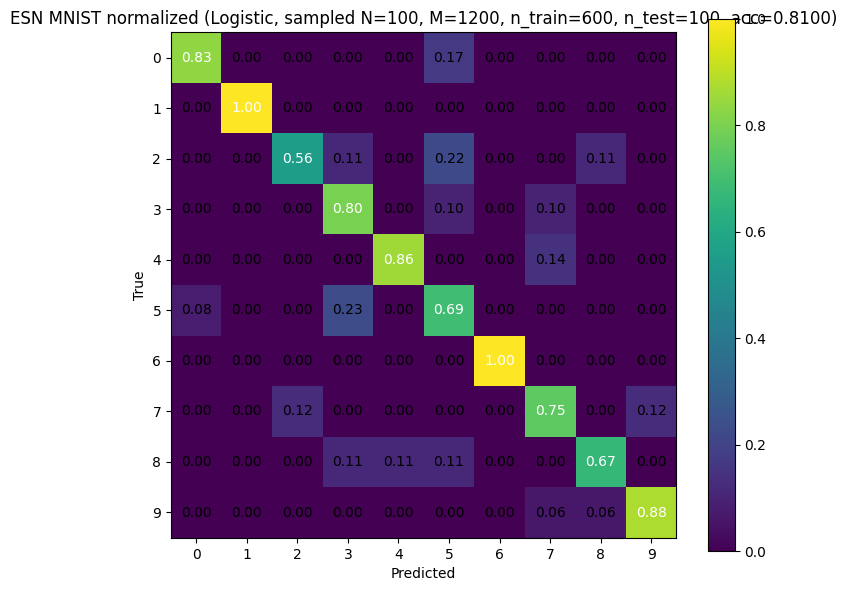

[Train] acc=1.0000
[Test ] acc=0.8100

Confusion matrix (test):
[[ 5  0  0  0  0  1  0  0  0  0]
 [ 0 14  0  0  0  0  0  0  0  0]
 [ 0  0  5  1  0  2  0  0  1  0]
 [ 0  0  0  8  0  1  0  1  0  0]
 [ 0  0  0  0  6  0  0  1  0  0]
 [ 1  0  0  3  0  9  0  0  0  0]
 [ 0  0  0  0  0  0  8  0  0  0]
 [ 0  0  1  0  0  0  0  6  0  1]
 [ 0  0  0  1  1  1  0  0  6  0]
 [ 0  0  0  0  0  0  0  1  1 14]]

Classification report (test):
              precision    recall  f1-score   support

           0     0.8333    0.8333    0.8333         6
           1     1.0000    1.0000    1.0000        14
           2     0.8333    0.5556    0.6667         9
           3     0.6154    0.8000    0.6957        10
           4     0.8571    0.8571    0.8571         7
           5     0.6429    0.6923    0.6667        13
           6     1.0000    1.0000    1.0000         8
           7     0.6667    0.7500    0.7059         8
           8     0.7500    0.6667    0.7059         9
           9     0.9333    0.8750

In [ ]:
if __name__ == "__main__":
    run_mnist_qrc_logreg_sampled(
        n_train=600,
        n_test=100,
        N=100,          # M=1200
        alpha=1.0,
        beta=0.7,
        squeeze_r=0.3,
        shots = 100,
        flip_p = 0.075,
        seed_data=123,
        seed_proj=0,
        seed_qrc=43,
        carry_state=True
    )

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


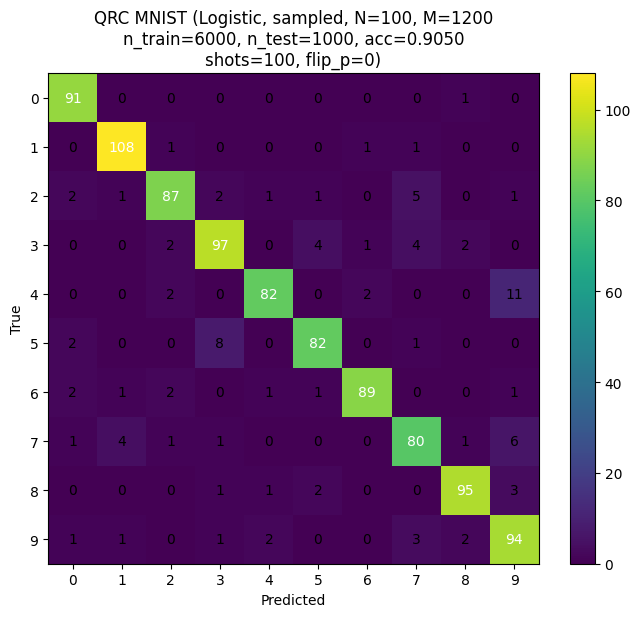

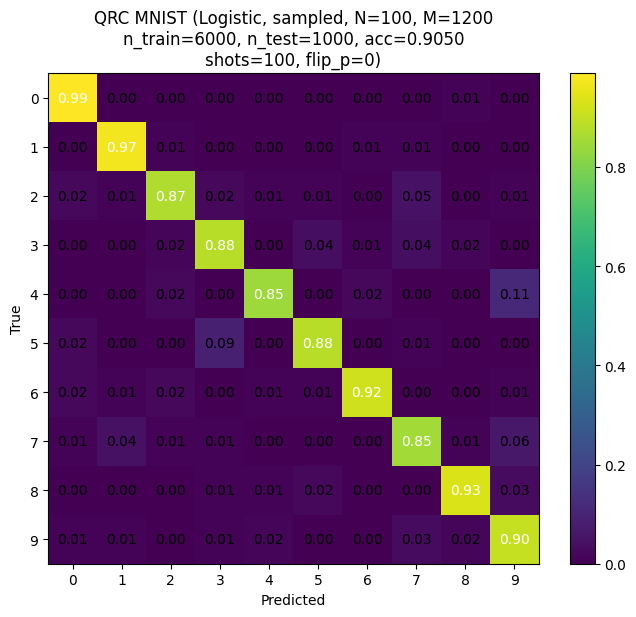

[Train] acc=1.0000
[Test ] acc=0.9050

Confusion matrix (test):
[[ 91   0   0   0   0   0   0   0   1   0]
 [  0 108   1   0   0   0   1   1   0   0]
 [  2   1  87   2   1   1   0   5   0   1]
 [  0   0   2  97   0   4   1   4   2   0]
 [  0   0   2   0  82   0   2   0   0  11]
 [  2   0   0   8   0  82   0   1   0   0]
 [  2   1   2   0   1   1  89   0   0   1]
 [  1   4   1   1   0   0   0  80   1   6]
 [  0   0   0   1   1   2   0   0  95   3]
 [  1   1   0   1   2   0   0   3   2  94]]

Classification report (test):
              precision    recall  f1-score   support

           0     0.9192    0.9891    0.9529        92
           1     0.9391    0.9730    0.9558       111
           2     0.9158    0.8700    0.8923       100
           3     0.8818    0.8818    0.8818       110
           4     0.9425    0.8454    0.8913        97
           5     0.9111    0.8817    0.8962        93
           6     0.9570    0.9175    0.9368        97
           7     0.8511    0.8511    0.85

In [ ]:
if __name__ == "__main__":
    run_mnist_qrc_logreg_sampled(
        n_train=6000,
        n_test=1000,
        N=100,          # M=1200
        alpha=1.0,
        beta=0.7,
        squeeze_r=0.3,
        shots = 100,
        flip_p = 0,
        seed_data=123,
        seed_proj=0,
        seed_qrc=43,
        carry_state=True
    )